# Quantitative analysis of spindle & chromosome dynamics in *Pyrrhocoris apterus*

Meiosis I, meiosis II, and mitosis — clean, reviewer-facing pipeline.
Run top-to-bottom (Kernel → Restart & Run All). Each figure has its own cell.

**Speed definition (uniform across all measures).** Each track is fitted with a four-parameter logistic used only to locate the end of directed movement (95% of its total change); anaphase onset is t=0 (or the first frame if imaging began later). The reported speed is the slope of a linear fit over that movement window, applied identically to chromosome-to-chromosome (C-C), pole-to-pole
(P-P) and pole-to-chromosome (P-C) distances.


In [1]:
# =============================================================================
# Imports and global configuration
# =============================================================================
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.patheffects as pe

# --- Input / output locations ------------------------------------------------
# BASE_DIR must contain the six tracking subfolders listed in FOLDER_MAP,
# plus the cell-area spreadsheet AREA_XLSX. All generated PDFs and the results
# workbook are written under OUTPUT_DIR/figures.
BASE_DIR   = "."
AREA_XLSX  = "Cell size overall.xlsx"
OUTPUT_DIR = "pipeline_output"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# --- Division types (fixed order used in every figure and table) -------------
DIVISIONS = ["Meiosis I", "Meiosis II", "Mitosis"]

# --- Map each input subfolder to (division, measurement type) ----------------
# 'chr-to-chr'   = chromosome-to-chromosome (C-C) distance over time
# 'pole-to-pole' = spindle pole-to-pole (P-P) distance over time
# Pole-to-chromosome (P-C) is derived later as (P-P - C-C)/2, not read from disk.
FOLDER_MAP = {
    "Chr_input_MeiosisI":   ("Meiosis I",  "chr-to-chr"),
    "Pole_input_MeiosisI":  ("Meiosis I",  "pole-to-pole"),
    "Chr_input_MeiosisII":  ("Meiosis II", "chr-to-chr"),
    "Pole_input_MeiosisII": ("Meiosis II", "pole-to-pole"),
    "Chr_input_Mitosis":    ("Mitosis",    "chr-to-chr"),
    "Pole_input_Mitosis":   ("Mitosis",    "pole-to-pole"),
}

# --- Global figure / print settings (set once) ------------------------------
# pdf.fonttype=42 keeps text editable in Illustrator; dpi=300 is print quality.
# Grid is left OFF globally so the main overlay figures (Fig 1/3) match the
# clean manuscript style; supplementary cells add grids locally where useful.
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 8, 
    "axes.labelsize": 8,
    "xtick.labelsize": 7, 
    "ytick.labelsize": 7, 
    "legend.fontsize": 7,
    "pdf.fonttype": 42, 
    "savefig.dpi": 300, 
    "axes.grid": False,
    "axes.spines.top": False, 
    "axes.spines.right": False,
})

TRACE_W = 3.35   # inches: one panel of a 2-column figure (~85 mm), placed at 100%
FIG4_W  = 2.30   # inches: one panel of a 3-column figure (~58 mm), placed at 100%

# --- Console table formatting -----------------------------------------------
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:7.2f}")

print("Config loaded. Figures ->", FIG_DIR)


Config loaded. Figures -> pipeline_output\figures


## 1. Load the data
Each CSV is one cell; the first two columns are time (s) and distance (µm).
`parse_cell_key` builds a cell ID independent of file format and of the measure
(chr vs pole), so a cell's two files share one key (needed for the
pole-to-chromosome calculation) while genuine sub-cells stay distinct.


In [2]:
def parse_cell_key(fn):
    """Build a cell identifier from a filename that is independent of format,
    of the measure (chr vs pole), and of whitespace/underscore variants.
    The measure is deliberately NOT part of the key, so a cell's chromosome
    and pole files collapse to the same key (required for the P-C calculation),
    while genuine sub-cells stay distinct via the position token."""
    b = os.path.basename(fn)
    # AL number with leading zeros removed (AL001, AL01, AL1 -> "AL1").
    m = re.search(r"AL0*(\d+)", b)
    al = f"AL{int(m.group(1))}" if m else b.split('_')[0]
    # Optional imaging scene, e.g. "scene2" -> "s2".
    sc = re.search(r"scene\s*([0-9]+)", b, re.I)
    scene = f"s{sc.group(1)}" if sc else ""
    # Optional position of the cell within a multi-cell field of view.
    pos = ("l" if re.search(r"lower", b, re.I)
           else "u" if re.search(r"upper", b, re.I)
           else "a" if re.search(r"(first|1st)\s*cell", b, re.I)
           else "b" if re.search(r"(second|2nd)\s*cell", b, re.I) else "")
    return "_".join(t for t in (al, scene, pos) if t)


def _find_subfolder(name):
    """Case-insensitive lookup of a subfolder inside BASE_DIR."""
    for e in os.listdir(BASE_DIR):
        p = os.path.join(BASE_DIR, e)
        if e.lower() == name.lower() and os.path.isdir(p):
            return p
    return None


def load_folder(fk):
    """Load every CSV in one input subfolder into a tidy long-format frame
    [cell, time_s, dist_um]. Only the first two columns of each CSV are used.
    A loud warning is printed if two files parse to the same cell key."""
    div, meas = FOLDER_MAP[fk]
    folder = _find_subfolder(fk)
    if folder is None:
        print("WARNING: missing", fk)
        return pd.DataFrame(columns=["cell", "time_s", "dist_um"])
    rows, seen = [], {}
    for path in sorted(glob.glob(os.path.join(folder, "*.csv"))):
        key = parse_cell_key(path)
        if key in seen:
            print(f"DUPLICATE '{key}' in {fk}: {seen[key]} / {os.path.basename(path)}")
        seen[key] = os.path.basename(path)
        df = pd.read_csv(path, sep=",", decimal=".").iloc[:, :2]
        if df.shape[1] < 2:
            df = pd.read_csv(path, sep=";", decimal=",").iloc[:, :2]
        df.columns = ["time_s", "dist_um"]
        df["time_s"]  = pd.to_numeric(df.time_s, errors="coerce")
        df["dist_um"] = pd.to_numeric(df.dist_um, errors="coerce")
        df = df.dropna().copy()
        df["cell"] = key
        rows.append(df[["cell", "time_s", "dist_um"]])
    out = (pd.concat(rows, ignore_index=True)
           if rows else pd.DataFrame(columns=["cell", "time_s", "dist_um"]))
    print(f"{div:11s} {meas:12s}: {out.cell.nunique():2d} cells | "
          f"{int((out.time_s < 0).sum())} pre-anaphase pts")
    return out


# Load all six subfolders into a dict keyed by (division, measure).
data = {FOLDER_MAP[fk]: load_folder(fk) for fk in FOLDER_MAP}


Meiosis I   chr-to-chr  : 20 cells | 95 pre-anaphase pts
Meiosis I   pole-to-pole: 19 cells | 95 pre-anaphase pts
Meiosis II  chr-to-chr  : 20 cells | 69 pre-anaphase pts
Meiosis II  pole-to-pole: 19 cells | 78 pre-anaphase pts
Mitosis     chr-to-chr  :  7 cells | 26 pre-anaphase pts
Mitosis     pole-to-pole:  7 cells | 27 pre-anaphase pts


## 2. Integrity checks (report only; data are never modified)
- **Correspondence:** every pole track should have a chromosome partner (for
  the P-C calculation); a chr-only cell is fine if the pole was not tracked.
- **Duplicate guard:** no cell counted under two divisions (`identical=False`
  means two genuinely different recordings that share an ID stem).
- **Geometry:** pole-to-pole ≥ chr-to-chr at every matched point — expect 0
  violations, since chromosomes lie between the poles.


In [3]:
def check_chr_pole_correspondence(data):
    """Report which chromosome tracks have a matching pole track, and flag
    likely scene/position label mismatches for those that do not."""
    print("\n=== chr / pole correspondence ===")
    al_of = lambda k: re.match(r"(AL\d+)", k).group(1)
    for div in DIVISIONS:
        c = set(data[(div, "chr-to-chr")].cell)
        p = set(data[(div, "pole-to-pole")].cell)
        print(f"\n{div}: chr={len(c)} pole={len(p)} matched={len(c & p)}")
        for x in sorted(c - p):
            part = [q for q in (p - c) if al_of(q) == al_of(x)]
            print(f"  chr-only : {x}" +
                  (f"  -> mismatch? {part}" if part else "  (no pole; ok)"))


def check_cross_division_duplicates(data):
    """Confirm no identical distance series appears under two divisions."""
    print("\n=== cross-division duplicate guard ===")
    for meas in ("chr-to-chr", "pole-to-pole"):
        seen = {}
        for div in DIVISIONS:
            for cell, g in data[(div, meas)].groupby("cell"):
                fp = hash(tuple(np.round(g.sort_values("time_s").dist_um.values, 4)))
                seen.setdefault(cell, []).append((div, fp))
        flagged = False
        for cell, e in seen.items():
            if len({d for d, _ in e}) > 1:
                print(f"  [{meas}] {cell} in {[d for d, _ in e]} | "
                      f"identical={len({f for _, f in e}) == 1}")
                flagged = True
        if not flagged:
            print(f"  [{meas}] OK")


def check_geometry(data):
    """At every matched time point, pole-to-pole must be >= chr-to-chr."""
    print("\n=== geometry (P-P >= C-C) ===")
    for div in DIVISIONS:
        m = pd.merge(data[(div, "pole-to-pole")], data[(div, "chr-to-chr")],
                     on=["cell", "time_s"], suffixes=("_pp", "_cc"))
        v = m[m.dist_um_pp < m.dist_um_cc]
        print(f"{div:11s}: {len(m):4d} matched, {len(v):3d} violations")

def al_of(k):
    m = re.match(r"(AL\d+)", k)
    return m.group(1) if m else k

check_chr_pole_correspondence(data)
check_cross_division_duplicates(data)
check_geometry(data)



=== chr / pole correspondence ===

Meiosis I: chr=20 pole=19 matched=19
  chr-only : AL46_s2  (no pole; ok)

Meiosis II: chr=20 pole=19 matched=19
  chr-only : AL37_s2_u  (no pole; ok)

Mitosis: chr=7 pole=7 matched=7

=== cross-division duplicate guard ===
  [chr-to-chr] OK
  [pole-to-pole] OK

=== geometry (P-P >= C-C) ===
Meiosis I  :  534 matched,   0 violations
Meiosis II :  420 matched,   0 violations
Mitosis    :  153 matched,   0 violations


## 3. Uniform speed extraction (logistic window-finder + linear speed)

For every track the chromosome-to-chromosome (C-C), the pole-to-pole (P-P), and the
derived pole-to-chromosome (P-C) is analysed with one identical procedure,
so the resulting velocities are directly comparable across all three measures.

1. **Locate the movement window with a bounded logistic.** A four-parameter
   logistic

   $$d(t) = a + \dfrac{b}{1 + e^{-(t - t_0)/k}}$$

   is fitted to each track ($a$ = metaphase/lower plateau, $a+b$ =
   anaphase/upper plateau, $t_0$ = inflection, $k$ = steepness). The fit is
   bounded so that shallow, non-saturating P-P traces cannot produce a
   degenerate steep inflection: $t_0$ is confined to the observation window,
   and for C-C the lower plateau is restricted to the measured congressed range
   (0–1.5 µm). The logistic is used **only** as a window-finder. The reported
   metaphase and final distances are the fitted curve evaluated at the window
   endpoints, d(0) and d(t_max) — see **4**.

2. **Define the window.** It runs from anaphase onset (t = 0, or the first
   frame if imaging began later) to the earlier of (i) the time the fit reaches
   95 % of its total change, or (ii) the last frame — the (ii) cap handling P-P
   traces that have not plateaued by the end of imaging.

3. **Speed definition (uniform across all measures).** Each track is fitted with a
   four-parameter logistic used only to locate the end of directed movement (95 %
   of its total change); anaphase onset is t = 0 (or the first frame if imaging
   began later). The reported speed is the slope of a linear fit over that movement
   window, applied identically to C-C, P-P and P-C distances. The metaphase
   (initial) and anaphase (final) distances are read from the fitted curve at the
   window endpoints — the fitted value at anaphase onset, d(0), and at the last
   frame, d(t_max) — not from the logistic's mathematical asymptotes

P-C distance is derived as (P-P − C-C)/2 at each matched time point (the
chromosomes lie between the poles).

In [4]:
# =============================================================================
# Uniform speed extraction (logistic window-finder + linear speed)
# =============================================================================

def sigmoid(t, a, b, t0, k):
    """Four-parameter logistic. a = lower (metaphase) plateau, a+b = upper
    (anaphase) plateau, t0 = inflection, k = steepness. Here the logistic is
    used ONLY to locate the movement window; the speed itself is linear."""
    return a + b / (1.0 + np.exp(-(t - t0) / k))


def analyse_windowed(time_s, dist_um, measure):
    """UNIFORM speed extraction for every measure (C-C, P-P, P-C).

    Step 1  Fit the logistic (bounded so shallow, non-saturating P-P traces
            cannot produce a degenerate steep inflection): t0 is confined to
            the observation window; for C-C the lower plateau a is bounded to
            the measured congressed range [0, 1.5] um.
    Step 2  Define the movement window: from anaphase onset (t=0, or the first
            frame if imaging began later) to the earlier of (i) the time the
            fit reaches 95% of its total change, or (ii) the last frame. The
            (ii) cap handles P-P traces that have not plateaued by the end.
    Step 3  Speed = slope of a LINEAR fit to the measured points in the window.

    Returns the two plateaus, the speed, the movement time, and everything
    needed to draw the annotated per-cell panel."""
    t = np.asarray(time_s, float)
    y = np.asarray(dist_um, float)
    o = np.argsort(t)
    t, y = t[o], y[o]

    # --- guard: a track needs a real time span to fit -----------------------
    if t.max() <= t.min():
        raise ValueError("no time span")

    # --- Step 1: bounded logistic fit ---------------------------------------
    a0 = np.median(y[:3])
    b0 = np.median(y[-3:]) - a0
    if abs(b0) < 1e-6:
        b0 = (y[-1] - y[0]) or 1.0
    # tighter lower-plateau bound for chromosome tracks only
    a_lo, a_hi = (0.0, 1.5) if measure == "C-C" else (y.min() - 20, y.max() + 20)
    a0 = min(max(a0, a_lo), a_hi)                       # keep guess in bounds
    p0 = [a0, b0, np.clip(np.median(t), t.min(), t.max()),
          max((t.max() - t.min()) / 8, 10)]
    popt, _ = curve_fit(sigmoid, t, y, p0=p0,
                        bounds=([a_lo, -80, t.min(), 1],
                                [a_hi,  80, t.max(), 5000]),
                        maxfev=50000)
    a, b, t0, k = popt
    r2log = 1 - np.sum((y - sigmoid(t, *popt)) ** 2) / np.sum((y - y.mean()) ** 2)

    # --- Step 2: movement window --------------------------------------------
    t_start = max(0.0, t.min())                         # onset, or first frame
    tt = np.linspace(t.min(), t.max(), 500)
    # find where the fit first reaches 95% of its total change (sign(b) handles
    # both rising C-C/P-P and falling P-C sigmoids)
    reached = tt[np.where((sigmoid(tt, *popt) - (a + 0.95 * b)) * np.sign(b) >= 0)[0]]
    t_end = min(reached[0], t.max()) if len(reached) else t.max()
    if t_end <= t_start:                                # safety for short/steep
        t_end = t.max()

    # --- Step 3: linear speed over the window -------------------------------
    m = (t >= t_start) & (t <= t_end)
    if m.sum() < 2:                                     # too few in-window pts
        m = np.ones_like(t, bool)                       # fall back to all points
    sl, ic, rlin, _, se = stats.linregress(t[m], y[m])

    return dict(a=a, b=b, t0=t0, k=k, r2_log=r2log,
                meta_plateau=a, ana_plateau=a + b,
                speed=sl * 60, speed_se=se * 60, r2_lin=rlin ** 2,
                initial=sigmoid(0.0, *popt), final=sigmoid(t.max(), *popt),
                t_start=t_start, t_end=t_end, move_time=(t_end - t_start) / 60,
                lin_slope=sl, lin_intercept=ic, mask=m, n=len(t))


def build_pc(data, div):
    """Pole-to-chromosome = (P-P - C-C)/2 at each matched time point
    (chromosomes lie between the poles). Requires a cell to have both tracks."""
    mrg = pd.merge(data[(div, "pole-to-pole")], data[(div, "chr-to-chr")],
                   on=["cell", "time_s"], suffixes=("_pp", "_cc"))
    mrg["dist_um"] = (mrg.dist_um_pp - mrg.dist_um_cc) / 2.0
    return mrg[["cell", "time_s", "dist_um"]]


def fit_all(data, min_points=6):
    """Apply analyse_windowed to every track of every measure and division.
    Tracks with too few points or a failed fit are recorded with a non-'ok'
    status rather than silently dropped."""
    rec = []

    def fm(df, div, meas):
        for cell, g in df.groupby("cell"):
            g = g.sort_values("time_s")
            if len(g) < min_points:
                rec.append(dict(division=div, measure=meas, cell=cell,
                                status="too_few", n=len(g)))
                continue
            try:
                rec.append(dict(division=div, measure=meas, cell=cell,
                                status="ok",
                                **analyse_windowed(g.time_s.values,
                                                   g.dist_um.values, meas)))
            except Exception as e:
                rec.append(dict(division=div, measure=meas, cell=cell,
                                status=f"fail:{type(e).__name__}", n=len(g)))

    for div in DIVISIONS:
        fm(data[(div, "pole-to-pole")], div, "P-P")
        fm(data[(div, "chr-to-chr")],   div, "C-C")
        fm(build_pc(data, div),          div, "P-C")
    return pd.DataFrame(rec)


# --- run the fitting --------------------------------------------------------
pc_data = {d: build_pc(data, d) for d in DIVISIONS}
fits = fit_all(data)
ok = fits[fits.status == "ok"].copy()
print("fits ok:", len(ok), "| status:", fits.status.value_counts().to_dict())


fits ok: 137 | status: {'ok': 137}


## 4. Group summary, chromosome-speed statistics, and anaphase A/B

All quantities use the uniform windowed-linear speed (the slope of a linear fit
over the logistic-defined movement window), so speeds are directly comparable
across chromosome-to-chromosome (C-C), pole-to-pole (P-P) and pole-to-chromosome
(P-C) measurements.

- **Group summary:** per division and measure, the metaphase and anaphase
  plateaus, the windowed-linear speed, and the median logistic and linear R².
- **Chromosome-speed statistics:** Welch's t-test on C-C speed between divisions,
  confirmed by the non-parametric Mann-Whitney U (small n; mitosis n = 7).
  p-values are reported for three pre-planned pairwise contrasts without
  multiple-comparison correction.
- **Anaphase A/B:** per-cell contribution of poleward chromosome movement
  (anaphase A) and spindle elongation (anaphase B), computed from paired changes
  in distance (A = 1 − ΔP-P/ΔC-C, B = ΔP-P/ΔC-C).


In [5]:
# =============================================================================
# Group summary, chromosome-speed statistics, and anaphase A/B split
# All quantities use the UNIFORM windowed-linear speed from the fitting cell
# (linear slope over a logistic-defined movement window). Speeds are therefore
# directly comparable across C-C, P-P and P-C.
# =============================================================================

def group_summary(fits):
    """Per (measure, division): n, mean +/- SD of the initial f(0) and final
    f(t_max) plateaus, the windowed-linear speed, and the median logistic R^2
    (window-finder quality) and median linear R^2 (speed-fit quality)."""
    rows = []
    for meas in ("P-P", "C-C", "P-C"):
        for div in DIVISIONS:
            s = fits[(fits.division == div) & (fits.measure == meas) & (fits.status == "ok")]
            rows.append(dict(division=div, measure=meas, n=len(s),
                initial=s.initial.mean(),   initial_sd=s.initial.std(),
                final=s.final.mean(),       final_sd=s.final.std(),
                speed=s.speed.mean(),       speed_sd=s.speed.std(),
                med_r2_log=s.r2_log.median(), med_r2_lin=s.r2_lin.median()))
    return pd.DataFrame(rows)

summary = group_summary(fits)
print(summary.to_string(index=False))

# --- Chromosome (C-C) segregation speed: Welch t-test + Mann-Whitney U ------
# n is small (mitosis n=7), so we confirm each parametric test with the
# non-parametric Mann-Whitney U. p-values are NOT corrected for the three
# pre-planned pairwise contrasts (stated in Methods).
print("\nChromosome (C-C) speed - Welch t-test and Mann-Whitney U:")
sp = lambda d: ok[(ok.division == d) & (ok.measure == "C-C")].speed.values
for a, b in [("Mitosis", "Meiosis I"), ("Mitosis", "Meiosis II"), ("Meiosis I", "Meiosis II")]:
    x, y = sp(a), sp(b)
    _, p_t = stats.ttest_ind(x, y, equal_var=False)          # Welch
    _, p_u = stats.mannwhitneyu(x, y, alternative="two-sided")
    slower = a if x.mean() < y.mean() else b
    print(f"  {a} ({x.mean():.2f}, n={len(x)}) vs {b} ({y.mean():.2f}, n={len(y)}): "
          f"Welch p={p_t:.3g} | MWU p={p_u:.3g}  -> {slower} slower")

# --- Anaphase A vs B contribution (from paired change in distance) ----------
def anaphase_ab_split(fits):
    """Per cell: anaphase B share = 100 * Delta(P-P)/Delta(C-C); A = 100 - B.
    Computed from paired distances (which add correctly), NOT from speeds.
    Requires a cell to have both P-P and C-C fits, so n = the paired count."""
    d = fits.assign(delta=fits.final - fits.initial)
    pc, summ = {}, []
    for div in DIVISIONS:
        pp = d[(d.division == div) & (d.measure == "P-P") & (d.status == "ok")].set_index("cell").delta
        cc = d[(d.division == div) & (d.measure == "C-C") & (d.status == "ok")].set_index("cell").delta
        both = pd.concat([pp.rename("dPP"), cc.rename("dCC")], axis=1).dropna()
        both["B"] = 100 * both.dPP / both.dCC
        both["A"] = 100 - both.B
        pc[div] = both
        summ.append(dict(division=div, n=len(both),
                         A_pct=both.A.mean(), A_sd=both.A.std(),
                         B_pct=both.B.mean(), B_sd=both.B.std()))
    return pc, pd.DataFrame(summ)

per_cell_ab, ab_summary = anaphase_ab_split(fits)
print("\nAnaphase A/B contribution (paired n per division):")
print(ab_summary.to_string(index=False))


  division measure  n  initial  initial_sd   final  final_sd   speed  speed_sd  med_r2_log  med_r2_lin
 Meiosis I     P-P 19    15.42        1.97   19.61      2.00    0.54      0.25        0.93        0.93
Meiosis II     P-P 19    13.36        1.39   16.29      1.26    0.46      0.32        0.91        0.86
   Mitosis     P-P  7     7.20        1.16   10.91      0.86    0.65      0.45        0.98        0.96
 Meiosis I     C-C 20     1.76        0.47   14.63      1.46    1.56      0.33        0.99        0.97
Meiosis II     C-C 20     1.39        0.33   12.74      0.87    1.64      0.26        0.99        0.97
   Mitosis     C-C  7     1.20        0.35    7.22      1.43    1.08      0.43        0.99        0.95
 Meiosis I     P-C 19     6.84        0.96    2.31      0.97   -0.55      0.09        0.98        0.95
Meiosis II     P-C 19     6.02        0.74    1.67      0.29   -0.63      0.11        0.99        0.96
   Mitosis     P-C  7     3.15        0.44    1.79      0.33   -0.37     

## 5. Scaling with cell size — pooled vs within-division

Here we ask whether final spindle length (P-P) and final chromosome separation
(C-C) scale with cell size. This analysis most affects the Discussion, so it is
done two ways:

- **Pooled** across all three division types, and
- **Within** each division separately.

The distinction is critical. A strong *pooled* correlation combined with flat
*within-division* correlations means the apparent "scaling with cell size" is a
difference *between division types* (small mitotic cells with short spindles vs
large meiotic cells with long spindles), not a continuous dependence on
cytoplasmic volume within a division — a classic pooling (Simpson's-paradox)
effect. This is exactly what we observe, and it is the honest framing for the
Discussion: spindle and chromosome dimensions are set by division identity, not
by continuous within-division scaling.

**Matching note.** Cell area lives in a separate spreadsheet whose IDs differ
from the tracking IDs (e.g. `AL40_1_upper cell` in the area file vs. `AL40_s1_u`
in the tracking data). `match_cc_to_area` pairs each area row to a fitted
chromosome-to-chromosome (C-C) track by **(division, AL number)**, and never
reuses a track, so no sub-cell is double-counted. Two situations require care:

- **Same AL number, different divisions.** Scene `AL46` contains one sub-cell in
  each division — `AL46b` (Meiosis I, area 597.5 µm²) and `AL46a` (Meiosis II,
  area 320.6 µm²). Because the pairing key includes division, these two
  genuinely different cells are matched to their correct tracks (`AL46_s2` and
  `AL46_s1`, respectively) and never confused.
- **Same AL number, same division.** When one AL number has two sub-cells within
  a single division (e.g. `AL40_s1_u` and `AL40_s3`, or the three `AL41`
  sub-cells in Meiosis II), the track whose fitted final spindle length is
  closest to the independently measured final spindle length (`final_PP`) in the
  area file is assigned.

The pairing is audited in **Table S2** (`TableS2_scaling_match.csv`/`.xlsx`):
47 matched cells, zero reused tracks, and the two Meiosis II cells with a C-C
track but no measured `final_PP` in the area file
(`AL41a_scene3_upper cell`, `AL41b_scene3_lower cell`) correctly carry a missing
`final_PP`. Note that the P-P scaling regression therefore rests on 45 cells
(20 Meiosis I + 18 Meiosis II + 7 mitosis), while the C-C scaling uses all 47
matched cells. This confirms the scaling analysis rests on unique,
non-reused cell↔area pairings.

In [6]:
# =============================================================================
# Scaling with cell size — pooled vs within-division
# =============================================================================

def load_cell_area(path):
    """Read the per-cell area / final-spindle-length table and normalise column
    names and division labels. Only the first data columns are used; trailing
    'Unnamed' columns hold stray summary/statistic cells and are dropped. An AL
    number is extracted for matching to the tracking data."""
    area = pd.read_excel(path)
    area.columns = [c.strip() for c in area.columns]
    area = area.rename(columns={"Cell area": "area",
                                "Final spindle length": "final_PP",
                                "Division": "division",
                                "Dataset": "dataset"})
    area = area[["dataset", "final_PP", "area", "division"]].copy()
    area = area.dropna(subset=["area", "division"])
    area["division"] = area["division"].str.strip()
    area["al"] = area["dataset"].apply(
        lambda s: int(re.search(r"AL0*(\d+)", str(s)).group(1))
        if re.search(r"AL0*(\d+)", str(s)) else np.nan)
    return area


def match_cc_to_area(area, fits):
    """Pair each area row to a fitted chromosome (C-C) track by (division, AL
    number). When one AL number has two sub-cells in a division, assign the
    track whose fitted final spindle length (fit_PP) is closest to the area
    file's measured final_PP; never reuse a track (prevents double-counting).
    Note: "chr-only" refers to the pole tracking; the area file's independently 
    measured final_PP may still exist for such cells, so AL46_s2 contributes 
    to P-P scaling via the area file"""
    cc = fits[(fits.measure == "C-C") & (fits.status == "ok")][
        ["division", "cell", "final"]].rename(columns={"final": "final_CC"})
    cc["al"] = cc.cell.apply(lambda s: int(re.search(r"AL0*(\d+)", s).group(1)))
    pp = fits[(fits.measure == "P-P") & (fits.status == "ok")][
        ["division", "cell", "final"]].rename(columns={"final": "fit_PP"})
    pp["al"] = pp.cell.apply(lambda s: int(re.search(r"AL0*(\d+)", s).group(1)))

    used, rows = set(), []
    for _, ar in area.sort_values("final_PP", ascending=False).iterrows():
        cand = cc[(cc.division == ar.division) & (cc.al == ar.al)
                  & (~cc.cell.isin(used))]                    # never reuse a track
        if len(cand) == 0:
            continue                                          # no unclaimed C-C track
        if len(cand) == 1 or np.isnan(ar.final_PP):
            best = cand.iloc[0]
        else:                                                 # disambiguate by P-P length
            m = cand.merge(pp, on=["division", "cell", "al"], how="left")
            m["d"] = (m.fit_PP - ar.final_PP).abs()
            best = m.sort_values("d", na_position="last").iloc[0]
        used.add(best.cell)                                   # claim it
        rows.append(dict(division=ar.division, area_dataset=ar.dataset,
                         area=ar.area, matched_cell=best.cell,
                         final_CC=best.final_CC))
    return pd.DataFrame(rows)


def scaling_regressions(area, cc_scaling):
    """Print pooled and within-division linear regressions for both scaling
    relationships. Near-flat within-division fits alongside a strong pooled fit
    are the key quantitative result (between-group, not continuous scaling)."""
    def report(label, df, xcol, ycol):
        print(f"\n{label}")
        for div in DIVISIONS:
            d = df[df.division == div].dropna(subset=[xcol, ycol])
            if len(d) > 2:
                sl, ic = np.polyfit(d[xcol], d[ycol], 1)
                r2 = np.corrcoef(d[xcol], d[ycol])[0, 1] ** 2
                print(f"  {div:11s}: n={len(d):2d}  y={sl:.4f}x+{ic:.2f}  R2={r2:.2f}")
        d = df.dropna(subset=[xcol, ycol])
        sl, ic = np.polyfit(d[xcol], d[ycol], 1)
        r2 = np.corrcoef(d[xcol], d[ycol])[0, 1] ** 2
        print(f"  {'pooled':11s}: n={len(d):2d}  y={sl:.4f}x+{ic:.2f}  R2={r2:.2f}")

    print("=" * 70, "\nSCALING WITH CELL SIZE: pooled vs within-division\n", "=" * 70)
    report("Final spindle length (P-P) vs cell area:", area, "area", "final_PP")
    report("Final chromosome separation (C-C) vs cell area:",
           cc_scaling, "area", "final_CC")


# --- run the scaling analysis ----------------------------------------------
area = load_cell_area(AREA_XLSX)
cc_scaling = match_cc_to_area(area, fits)

# Cell-size group means, recomputed from the raw area values.
print("Cell-size group means (area, µm²):")
print(area.groupby("division")["area"].agg(["size", "mean", "std"]).to_string())

# Duplicate audit: confirm no fitted C-C track was assigned to two area rows.
dups = cc_scaling[cc_scaling.duplicated("matched_cell", keep=False)]
print("\nDuplicate matched tracks:",
      "none" if len(dups) == 0
      else dups[["area_dataset", "matched_cell"]].to_string(index=False))

scaling_regressions(area, cc_scaling)

print(f"\nChromosome scaling matched n = {len(cc_scaling)}")


Cell-size group means (area, µm²):
            size    mean     std
division                        
Meiosis I     20  585.39  104.79
Meiosis II    20  353.35   46.02
Mitosis        7   84.38   10.50

Duplicate matched tracks: none
SCALING WITH CELL SIZE: pooled vs within-division

Final spindle length (P-P) vs cell area:
  Meiosis I  : n=20  y=0.0066x+15.79  R2=0.12
  Meiosis II : n=18  y=0.0026x+15.65  R2=0.01
  Mitosis    : n= 7  y=0.0571x+6.12  R2=0.42
  pooled     : n=45  y=0.0151x+10.77  R2=0.74

Final chromosome separation (C-C) vs cell area:
  Meiosis I  : n=20  y=-0.0026x+16.17  R2=0.04
  Meiosis II : n=20  y=0.0073x+10.17  R2=0.15
  Mitosis    : n= 7  y=0.0466x+3.29  R2=0.12
  pooled     : n=47  y=0.0114x+8.04  R2=0.61

Chromosome scaling matched n = 47


## 6. Plotting

In [7]:
# --- Shared colourblind-safe palettes & markers (SINGLE source of truth) ----
# MEASURE palette (Fig 1/3 traces, Fig 4 anaphase & speeds): blue / sand / red.
# Built from blue + red + yellow hues (Paul Tol), avoiding the red-green
# confusion axis; hues also differ in brightness so they separate in grayscale
# and under colour-vision deficiency. Distinct MARKERS add redundant encoding.
MEAS_STYLE = {
    "P-P": dict(color="#4477AA", marker="o", label="P-P"),
    "P-C": dict(color="#DDAA33", marker="s", label="P-C"),
    "C-C": dict(color="#CC3311", marker="^", label="C-C"),
}
MEAS = {k: v["color"] for k, v in MEAS_STYLE.items()}

# DIVISION palette (Fig 4 area & scaling): purple / teal / grey - a DISJOINT
# palette so a colour never means two things across the figure set.
DIV_STYLE = {
    "Meiosis I":  dict(color="#AA3377", marker="o", label="Meiosis I"),
    "Meiosis II": dict(color="#009988", marker="s", label="Meiosis II"),
    "Mitosis":    dict(color="#666666", marker="^", label="Mitosis"),
}
DIV = {k: v["color"] for k, v in DIV_STYLE.items()}

# mean marker (white diamond)
MEAN_KW = dict(marker="d", s=28, color="white", alpha=0.95,
               edgecolors="black", zorder=5)
LEGEND_KW = dict(fontsize=8, loc="upper left", frameon=True, framealpha=0.9)


In [8]:
def binned_mean(src, bin_s, t_lo, t_hi):
    """Average all cells' points into fixed-width, onset-CENTERED time bins
    (0 is a bin centre), but only within the inner range [t_lo, t_hi] seconds.
    Points outside this range are ignored, so the first/last plotted bins sit
    inside the axis limits with margin. Returns bin-centre time (s), mean, SEM,
    and n per bin."""
    d = src.dropna(subset=["time_s", "dist_um"]).copy()
    d = d[(d.time_s >= t_lo) & (d.time_s <= t_hi)] 
    if len(d) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    k_lo = np.floor((t_lo + bin_s/2) / bin_s)
    k_hi = np.ceil( (t_hi + bin_s/2) / bin_s)
    edges = (np.arange(k_lo, k_hi + 1) - 0.5) * bin_s
    d["bin"] = pd.cut(d.time_s, edges, include_lowest=True)
    g = d.groupby("bin", observed=True)["dist_um"].agg(["mean", "std", "size"])
    g = g[g["size"] >= 2]
    centres = np.array([iv.mid for iv in g.index])
    sem = g["std"].values / np.sqrt(g["size"].values)
    return centres, g["mean"].values, sem, g["size"].values


def all_points_panel(division, ax, ylim, xlim_min, bin_s=60,
                     margin_min=1.0, show_points=False, min_n=2):
    """Per division: onset-centred binned-mean trajectory (+/-SEM) for P-P, P-C,
    C-C. The AXIS keeps the fixed manuscript range (xlim_min, in minutes), but
    BINNING is confined to an inner range inset by margin_min on each side, so
    the first/last bin never touches the left/right border. Time in minutes;
    colourblind-safe (distinct colour AND marker per measure)."""
    xlo_s = (xlim_min[0] + margin_min) * 60.0 
    xhi_s = (xlim_min[1] - margin_min) * 60.0
    series = [("P-P", data[(division, "pole-to-pole")]),
              ("P-C", pc_data[division]),
              ("C-C", data[(division, "chr-to-chr")])]
    for lbl, src in series:
        st = MEAS_STYLE[lbl]
        if show_points:
            pts = src[(src.time_s >= xlo_s) & (src.time_s <= xhi_s)]
            ax.scatter(pts.time_s / 60.0, pts.dist_um, s=3, color=st["color"],
                       alpha=0.25, edgecolors="none")
        cx, my, sem, n = binned_mean(src, bin_s, xlo_s, xhi_s)
        if len(cx) == 0:
            continue
        idx = np.where(n >= min_n)[0]
        if len(idx) == 0:
            continue
        sl = slice(idx[0], idx[-1] + 1)
        cx, my, sem = cx[sl], my[sl], sem[sl]
        cx_min = cx / 60.0
        ax.fill_between(cx_min, my - sem, my + sem, color=st["color"], alpha=0.20)
        ax.plot(cx_min, my, "-", color=st["color"], lw=1.0) 
        ax.plot(cx_min, my, st["marker"], color=st["color"], ms=3,
                label=st["label"], mec="white", mew=0.3) 
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel("Time [min]"); ax.set_ylabel("Distance [µm]")
    ax.set_xlim(*xlim_min); ax.set_ylim(*ylim)
    ax.legend(fontsize=7, loc="upper left", markerscale=1.2,
              handlelength=1.2, handletextpad=0.4, borderpad=0.3) 


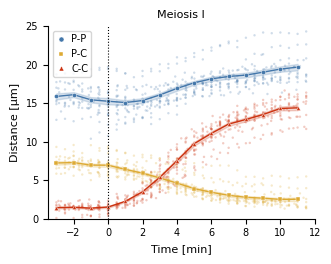

In [9]:
fig, ax = plt.subplots(figsize=(TRACE_W, TRACE_W*0.8))
all_points_panel("Meiosis I", ax, ylim=(0, 25), xlim_min=(-3.5, 12),
                 bin_s=60, margin_min=0.5, show_points=True)
ax.set_title("Meiosis I")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig1C_MeiosisI.pdf"), bbox_inches="tight"); plt.show()


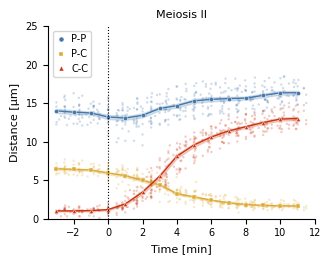

In [10]:
fig, ax = plt.subplots(figsize=(TRACE_W, TRACE_W*0.8))
all_points_panel("Meiosis II", ax, ylim=(0, 25), xlim_min=(-3.5, 12),
                 bin_s=60, margin_min=0.5, show_points=True)
ax.set_title("Meiosis II")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig1F_MeiosisII.pdf"), bbox_inches="tight"); plt.show()


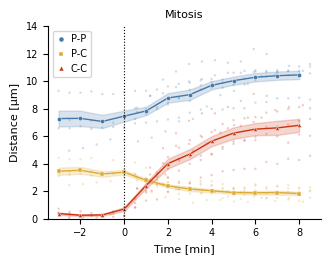

In [11]:
fig, ax = plt.subplots(figsize=(TRACE_W, TRACE_W*0.8)) 
all_points_panel("Mitosis", ax, ylim=(0, 14), xlim_min=(-3.5, 9),
                 bin_s=60, margin_min=0.5, show_points=True)
ax.set_title("Mitosis")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig3C_Mitosis.pdf"), bbox_inches="tight"); plt.show()


In [12]:
def scaling_scatter(ax, df, xcol, ycol, ylab):
    """Per-division points + within-division fits + pooled fit. Fit lines are
    drawn ON TOP of the points (higher zorder, white halo) so they stay visible
    even where points cluster; only the pooled R2 is annotated."""
    for div in DIVISIONS:
        d = df[df.division == div].dropna(subset=[xcol, ycol])
        st = DIV_STYLE[div]
        ax.scatter(d[xcol], d[ycol], marker=st["marker"], s=16,
                   color=st["color"], alpha=0.85, label=div, zorder=2)
        if len(d) > 2:
            sl, ic = np.polyfit(d[xcol], d[ycol], 1)
            xs = np.linspace(d[xcol].min(), d[xcol].max(), 20)
            ax.plot(xs, sl * xs + ic, "-", lw=2.0, color=st["color"],
                    solid_capstyle="round", zorder=5, 
                    path_effects=[pe.Stroke(linewidth=3.2, foreground="white"),
                                  pe.Normal()]) 
    dd = df.dropna(subset=[xcol, ycol])
    sl, ic = np.polyfit(dd[xcol], dd[ycol], 1)
    r2 = np.corrcoef(dd[xcol], dd[ycol])[0, 1] ** 2
    xs = np.linspace(dd[xcol].min(), dd[xcol].max(), 50)
    ax.plot(xs, sl * xs + ic, "k--", lw=1.5, zorder=6) 
    ax.text(0.03, 0.97, f"pooled R²={r2:.2f}", transform=ax.transAxes, 
            fontsize=7, va="top", fontweight="bold")
    ax.set_xlabel("Cell area [µm²]"); ax.set_ylabel(ylab)
    ax.legend(**{**LEGEND_KW, "loc": "lower right", "fontsize": 6,
                 "handlelength": 1.0, "handletextpad": 0.3, "borderpad": 0.3})
    return sl, ic, r2

def stars(p):
    return "****" if p<1e-4 else "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<0.05 else "ns"

def sig_bar(ax, x1, x2, y, p, fs=8, pad=None):
    """Horizontal line with the star ABOVE it, separated by a small gap so the
    glyph never touches the line (pad defaults to ~2% of the current y-range)."""
    ax.plot([x1, x2], [y, y], "k-", lw=0.8)
    if pad is None:
        y0, y1 = ax.get_ylim(); pad = -0.015 * (y1 - y0)
    ax.text((x1 + x2) / 2, y + pad, stars(p), ha="center", va="bottom", fontsize=fs)

n: 20 20 7


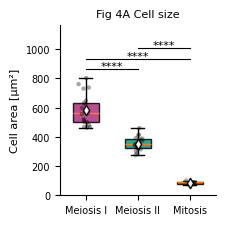

In [13]:
# Fig 4A - cell area per division. Individual cells: transparent black circles.
# Group mean: white diamond. Division palette (purple/teal/grey).
# Pairwise Welch stars.
fig, ax = plt.subplots(figsize=(FIG4_W, FIG4_W))
mi1 = area[area.division == "Meiosis I"].area.dropna().values
mi2 = area[area.division == "Meiosis II"].area.dropna().values
mit = area[area.division == "Mitosis"].area.dropna().values
groups = [mi1, mi2, mit]
print("n:", len(mi1), len(mi2), len(mit)) 

bp = ax.boxplot(groups, tick_labels=["Meiosis I", "Meiosis II", "Mitosis"],
                widths=0.5, patch_artist=True, showmeans=False, showfliers=False) 
for patch, d in zip(bp["boxes"], DIVISIONS):
    patch.set(facecolor=DIV[d], alpha=0.85)

rng = np.random.default_rng(0)
for pos, g in enumerate(groups, start=1):
    ax.scatter(rng.normal(pos, 0.06, len(g)), g,
               s=10, color="black", alpha=0.35, edgecolors="none", zorder=3) 
ax.scatter([1, 2, 3], [g.mean() for g in groups], **MEAN_KW)
ax.set_ylabel("Cell area [µm²]");

ymax = max(g.max() for g in groups); h = ymax * 0.05
for i, (a, b) in enumerate([(0, 1), (0, 2), (1, 2)]):
    _, p = stats.ttest_ind(groups[a], groups[b], equal_var=False)
    y = ymax + h * (1.5 + 1.8 * i)
    sig_bar(ax, a+1, b+1, y, p)
ax.set_ylim(0, ymax + h * 9) 

ax.set_title("Fig 4A Cell size")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4A_cellarea.pdf"), bbox_inches="tight"); plt.show()


paired n: {'Meiosis I': 19, 'Meiosis II': 19, 'Mitosis': 7}


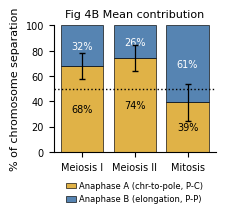

In [14]:
# Fig 4B - Anaphase A vs B, mean stacked contribution. MEASURE palette:
# anaphase A (P-C-derived) = sand, anaphase B (P-P-derived) = blue. One boundary
# error bar (A SD == B SD, since B = 100 - A). Width matches the original
# 2-panel figure (FIG4_W*2), so this is a standalone full-width panel.
CB_A = MEAS["P-C"]     # sand  (anaphase A, from P-C)
CB_B = MEAS["P-P"]     # blue  (anaphase B, from P-P)

fig, ax1 = plt.subplots(figsize=(FIG4_W, FIG4_W))
x = np.arange(len(DIVISIONS))
Am = [per_cell_ab[d].A.mean() for d in DIVISIONS]
Bm = [per_cell_ab[d].B.mean() for d in DIVISIONS]
Asd = [per_cell_ab[d].A.std() for d in DIVISIONS]
print("paired n:", {d: len(per_cell_ab[d]) for d in DIVISIONS})

ax1.bar(x, Am, color=CB_A, alpha=0.9, edgecolor="black", linewidth=0.5,
        label="Anaphase A (chr-to-pole, P-C)")
ax1.bar(x, Bm, bottom=Am, color=CB_B, alpha=0.9, edgecolor="black",
        linewidth=0.5, label="Anaphase B (elongation, P-P)")
ax1.errorbar(x, Am, yerr=Asd, fmt="none", ecolor="black", capsize=2.5, lw=0.9, zorder=5)
ax1.axhline(50, color="k", ls=":", lw=1)
for k, (a, b) in enumerate(zip(Am, Bm)):
    ax1.text(k, a*0.5, f"{a:.0f}%", ha="center", va="center", fontsize=7)
    ax1.text(k, a + b*0.5, f"{b:.0f}%", ha="center", va="center", fontsize=7, color="white")
ax1.set_xticks(x); ax1.set_xticklabels(DIVISIONS)
ax1.set_ylabel("% of chromosome separation"); ax1.set_ylim(0, 100)
ax1.set_title("Fig 4B Mean contribution")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1,
           fontsize=6, frameon=False, handlelength=1.2,
           handletextpad=0.4, borderpad=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4B_anaphaseAB_mean.pdf"), bbox_inches="tight"); plt.show()


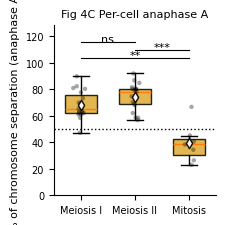

In [15]:
# Fig 4C - Per-cell anaphase A share, boxplot + individual cells + white-diamond
# means (matching Fig 4A) + Welch stars. Anaphase A (P-C-derived) = sand.
CB_A = MEAS["P-C"]

fig, ax2 = plt.subplots(figsize=(FIG4_W, FIG4_W))
x = np.arange(len(DIVISIONS)); rng = np.random.default_rng(0)
Avals = [per_cell_ab[d].A.dropna().values for d in DIVISIONS]

bp = ax2.boxplot(Avals, positions=x, widths=0.6, patch_artist=True,
                 showmeans=False, showfliers=False)
for patch in bp["boxes"]:
    patch.set(facecolor=CB_A, alpha=0.85)
for k, a in enumerate(Avals):
    ax2.scatter(rng.normal(k, 0.06, len(a)), a, s=10,
                color="black", alpha=0.35, edgecolors="none", zorder=3)
ax2.scatter(x, [a.mean() for a in Avals], **MEAN_KW)
ax2.axhline(50, color="k", ls=":", lw=1)
h = 3.5
for i, (a, b) in enumerate([(0, 2), (1, 2), (0, 1)]):
    _, p = stats.ttest_ind(Avals[a], Avals[b], equal_var=False)
    y = 100 + h * (1 + 1.7 * i)
    sig_bar(ax2, a, b, y, p)
ax2.set_xticks(x); ax2.set_xticklabels(DIVISIONS)
ax2.set_ylabel("% of chromosome separation (anaphase A)")
ax2.set_ylim(0, 100 + h*8)
ax2.set_title("Fig 4C Per-cell anaphase A")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4C_anaphaseA_percell.pdf"), bbox_inches="tight"); plt.show()


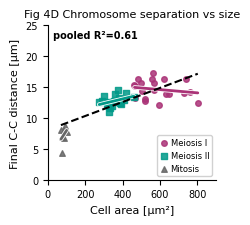

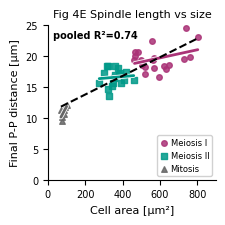

In [16]:
# Fig 4D - final C-C vs cell area (division palette from scaling_scatter).
fig, ax = plt.subplots(figsize=(FIG4_W, FIG4_W)) 
scaling_scatter(ax, cc_scaling, "area", "final_CC", "Final C-C distance [µm]")
ax.set_ylim(0, 25); ax.set_xlim(0, 900)
ax.set_title("Fig 4D Chromosome separation vs size")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4D_CC_scaling.pdf"), bbox_inches="tight"); plt.show()

# Fig 4E - final P-P vs cell area.
fig, ax = plt.subplots(figsize=(FIG4_W, FIG4_W)) 
scaling_scatter(ax, area, "area", "final_PP", "Final P-P distance [µm]")
ax.set_ylim(0, 25); ax.set_xlim(0, 900)
ax.set_title("Fig 4E Spindle length vs size")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4E_PP_scaling.pdf"), bbox_inches="tight"); plt.show()


C-C n: [20, 20, 7] | P-P n: [19, 19, 7]


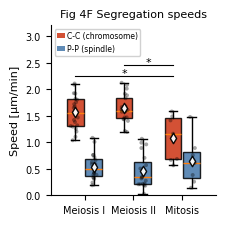

In [17]:
# Fig 4F - C-C and P-P segregation speeds per division. MEASURE palette:
# C-C = red, P-P = blue (matching the trace figures). Individual cells: black
# dots. Group means: white diamonds. Significant C-C mitosis contrasts starred.
fig, ax = plt.subplots(figsize=(FIG4_W, FIG4_W))
x = np.arange(len(DIVISIONS)); w = 0.38; rng = np.random.default_rng(0)
cc = [ok[(ok.division == d) & (ok.measure == "C-C")].speed.dropna().values for d in DIVISIONS]
pp = [ok[(ok.division == d) & (ok.measure == "P-P")].speed.dropna().values for d in DIVISIONS]
print("C-C n:", [len(v) for v in cc], "| P-P n:", [len(v) for v in pp]) 

bp_cc = ax.boxplot(cc, positions=x - w/2, widths=w*0.9, patch_artist=True,
                   showmeans=False, showfliers=False)
bp_pp = ax.boxplot(pp, positions=x + w/2, widths=w*0.9, patch_artist=True,
                   showmeans=False, showfliers=False)
for patch in bp_cc["boxes"]: patch.set(facecolor=MEAS["C-C"], alpha=0.85) 
for patch in bp_pp["boxes"]: patch.set(facecolor=MEAS["P-P"], alpha=0.85) 

# individual cells (small black dots)
for i in range(len(DIVISIONS)):
    ax.scatter(rng.normal(x[i]-w/2, 0.04, len(cc[i])), cc[i], s=8,
               color="black", alpha=0.35, edgecolors="none", zorder=3)
    ax.scatter(rng.normal(x[i]+w/2, 0.04, len(pp[i])), pp[i], s=8,
               color="black", alpha=0.35, edgecolors="none", zorder=3)
# group means (white diamonds)
ax.scatter(x - w/2, [v.mean() for v in cc], **MEAN_KW)
ax.scatter(x + w/2, [v.mean() for v in pp], **MEAN_KW)

# significance: ONLY sig_bar (plain horizontal line, star above with a small
# gap). The two significant C-C contrasts both involve mitosis (rightmost box).
ymax = max(v.max() for v in cc + pp); h = ymax * 0.06
for i, (a, b) in enumerate([(0, 2), (1, 2)]):
    _, p = stats.ttest_ind(cc[a], cc[b], equal_var=False)
    y = ymax + h * (1 + 1.6 * i)
    sig_bar(ax, x[a]-w/2, x[b]-w/2, y, p) 

# legend: measures only, in the clear UPPER-LEFT
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=MEAS["C-C"], alpha=0.85, label="C-C (chromosome)"),
                   Patch(facecolor=MEAS["P-P"], alpha=0.85, label="P-P (spindle)")],
          loc="upper left", fontsize=5.5, frameon=True, framealpha=0.9,
          handlelength=1.0, handletextpad=0.3, borderpad=0.3)
ax.set_xticks(x); ax.set_xticklabels(DIVISIONS)
ax.set_ylabel("Speed [\u00b5m/min]"); ax.set_ylim(0, ymax + h*8.5)
ax.set_title("Fig 4F Segregation speeds")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "Fig4F_speeds.pdf"), bbox_inches="tight"); plt.show()


## 7. Supplementary figures — raw traces (S1), logistic fits + plateaus (S2), linear fits + speed & movement time (S3), movement-time summary (S4)

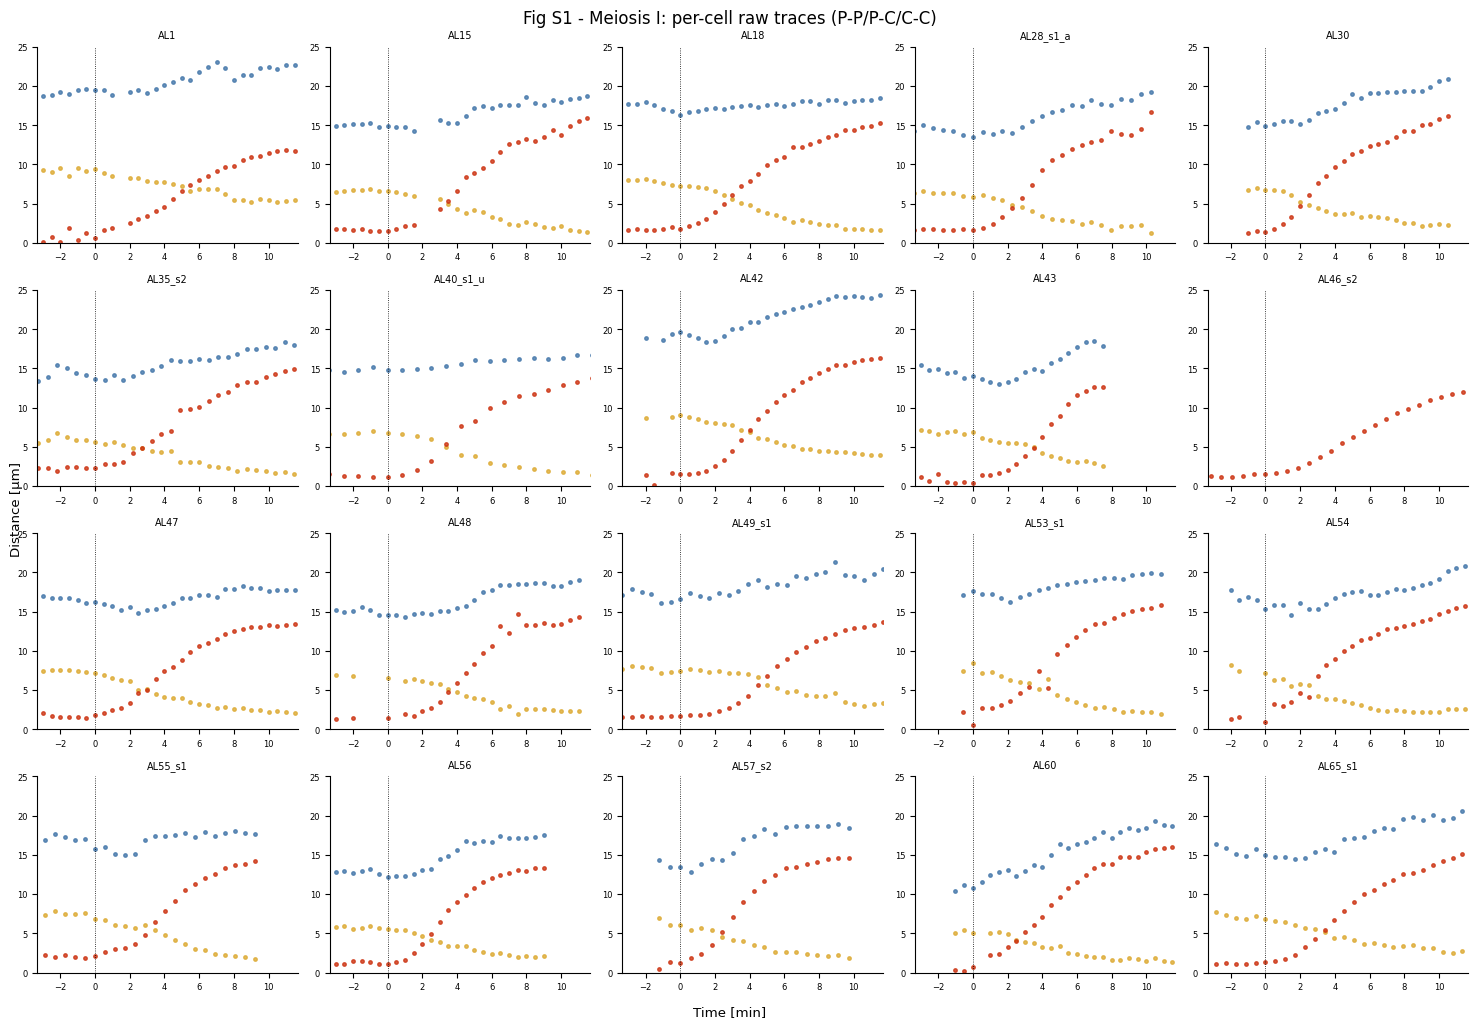

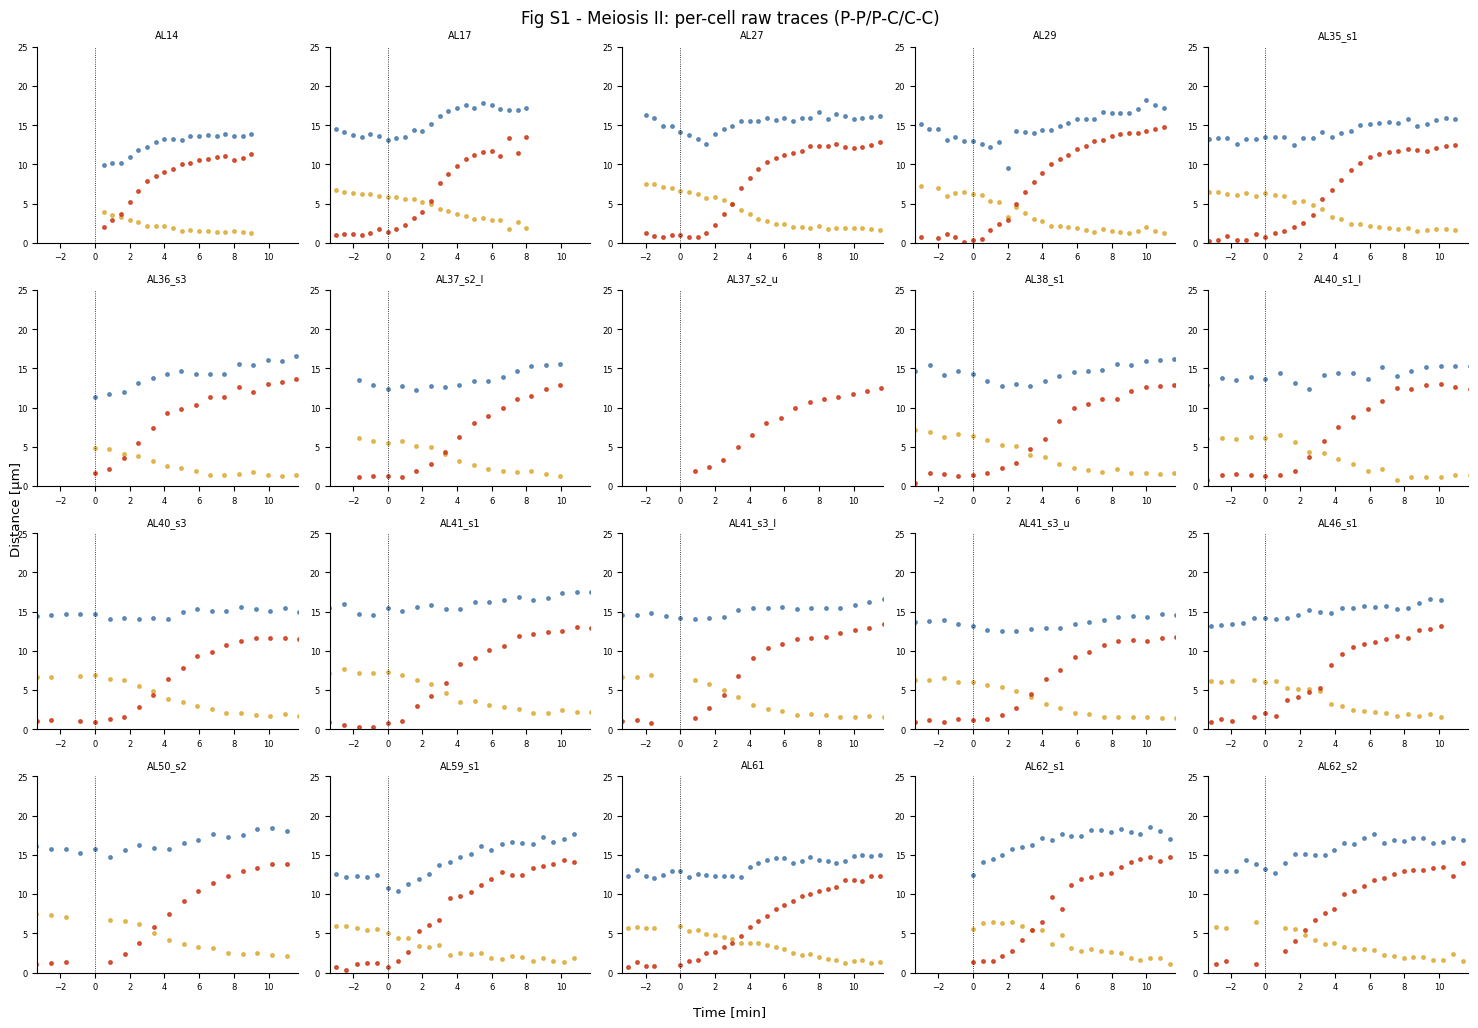

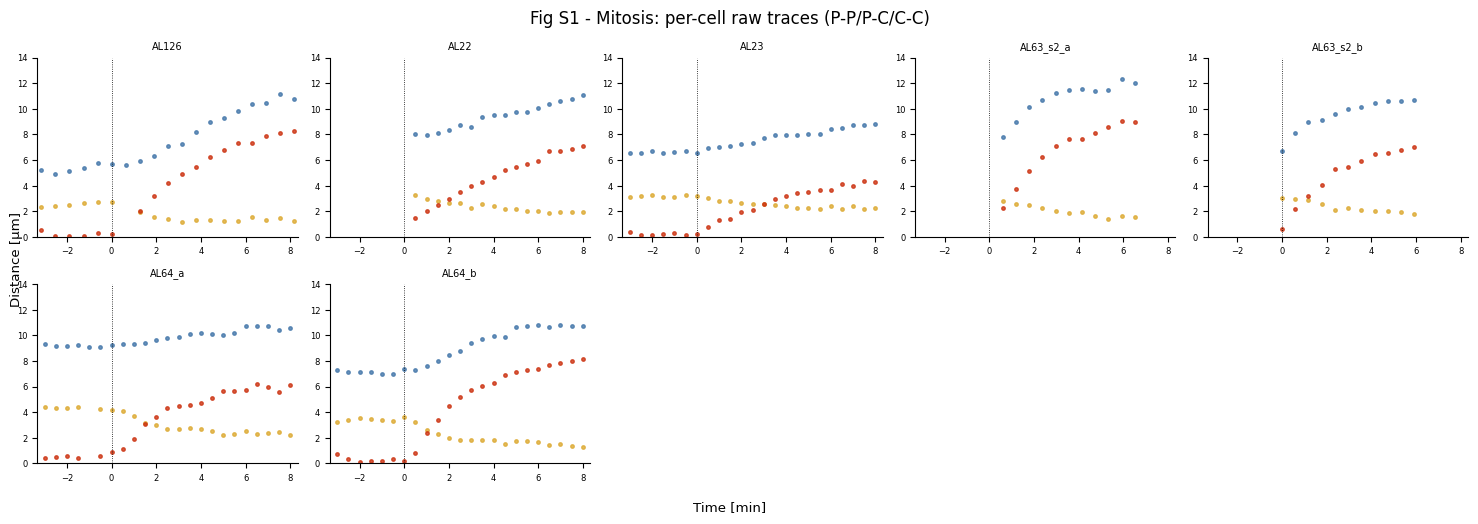

In [18]:
# Fig S1 - per-cell RAW trace galleries (no fit, no R²). One page per division;
# each small panel is one cell, all three measures as raw points (P-P blue,
# P-C sand, C-C red). Y-AXIS IS FIXED PER DIVISION so every cell in a page is
# directly comparable. Fits/R² are shown in S2 (logistic) and S3 (linear).
def fig_s1_gallery(division, ylim, xlim_min, ncol=5, fname=None):
    cells = sorted(set(fits[(fits.division == division) & (fits.status == "ok")].cell))
    n = len(cells); nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.0*ncol, 2.6*nrow), squeeze=False)
    series = [("P-P", "pole-to-pole", MEAS["P-P"]),
              ("P-C", None,           MEAS["P-C"]),
              ("C-C", "chr-to-chr",   MEAS["C-C"])]
    for j, cell in enumerate(cells):
        ax = axes[j // ncol][j % ncol]
        for lbl, key, col in series:
            src = (pc_data[division] if lbl == "P-C" else data[(division, key)])
            g = src[src.cell == cell].sort_values("time_s")
            if len(g):
                ax.plot(g.time_s/60.0, g.dist_um, "o", ms=2.5, color=col, alpha=0.8)
        ax.axvline(0, color="k", ls=":", lw=0.6)
        ax.set_xlim(*xlim_min); ax.set_ylim(*ylim)
        ax.set_title(cell, fontsize=7); ax.tick_params(labelsize=6)
    for j in range(n, nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.supxlabel("Time [min]"); fig.supylabel("Distance [µm]")
    fig.suptitle(f"Fig S1 - {division}: per-cell raw traces (P-P/P-C/C-C)", fontsize=12)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight")
    plt.show()

fig_s1_gallery("Meiosis I",  ylim=(0, 25), xlim_min=(-3.33, 11.67), fname="FigS1a_MeiosisI_traces.pdf")
fig_s1_gallery("Meiosis II", ylim=(0, 25), xlim_min=(-3.33, 11.67), fname="FigS1b_MeiosisII_traces.pdf")
fig_s1_gallery("Mitosis",    ylim=(0, 14), xlim_min=(-3.33, 8.33),  fname="FigS1c_Mitosis_traces.pdf")


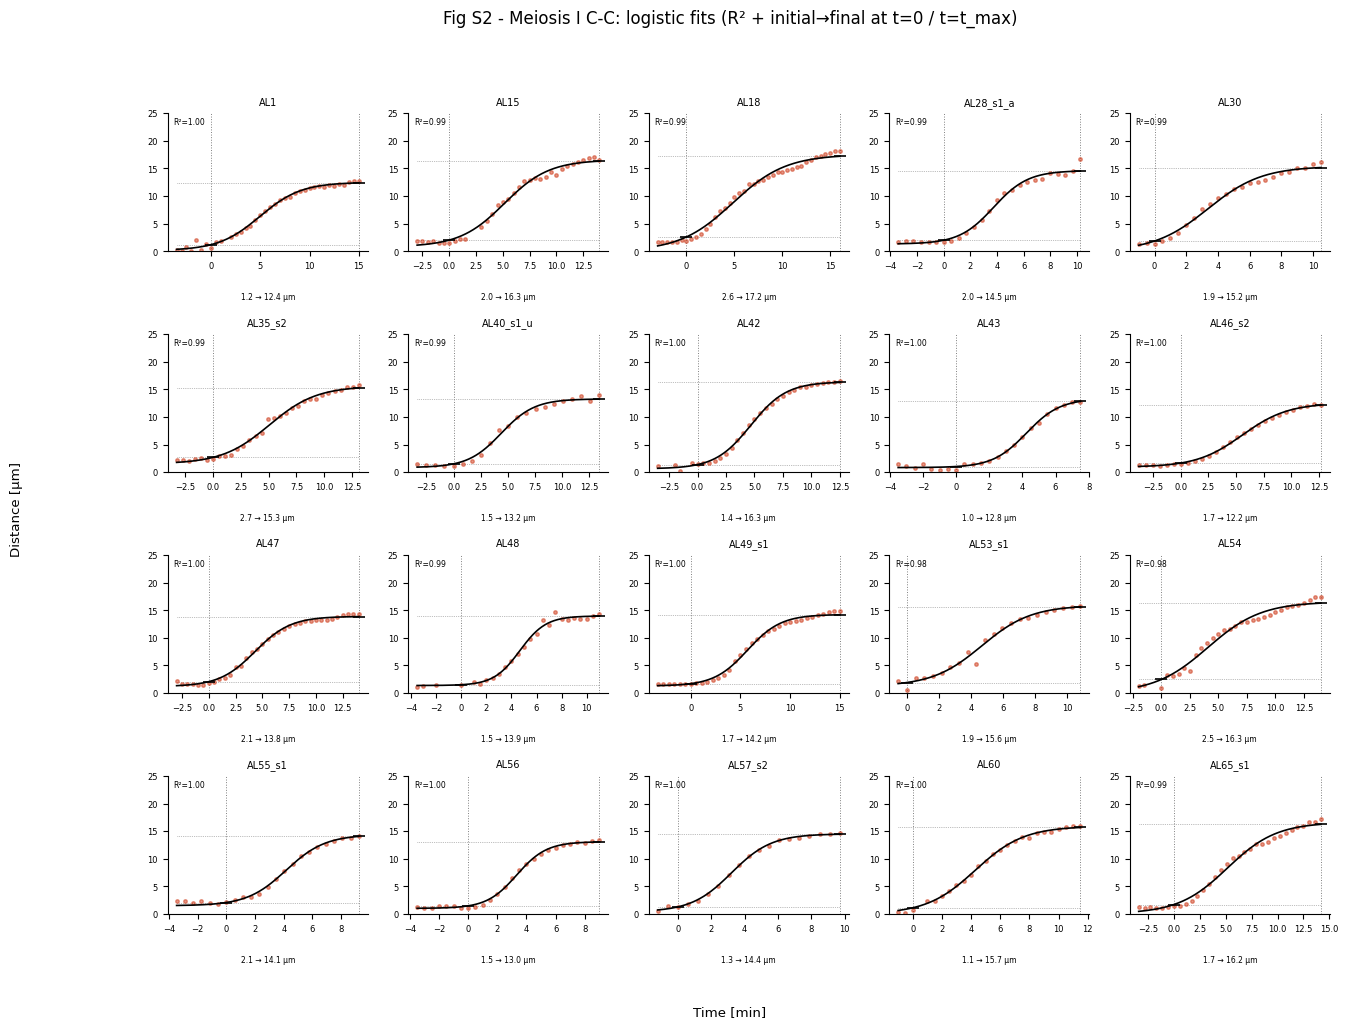

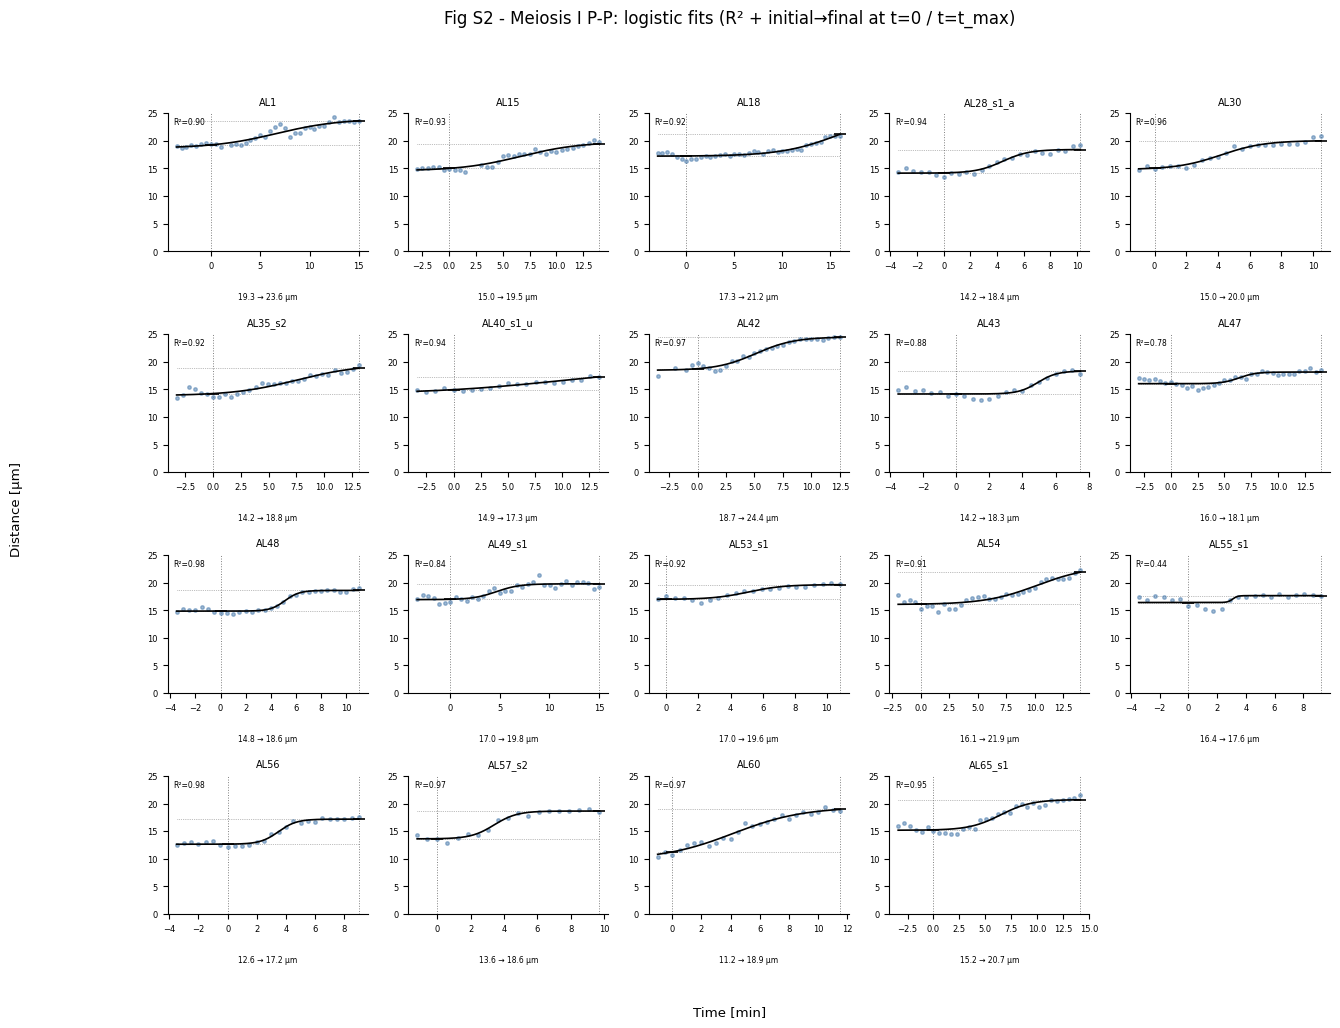

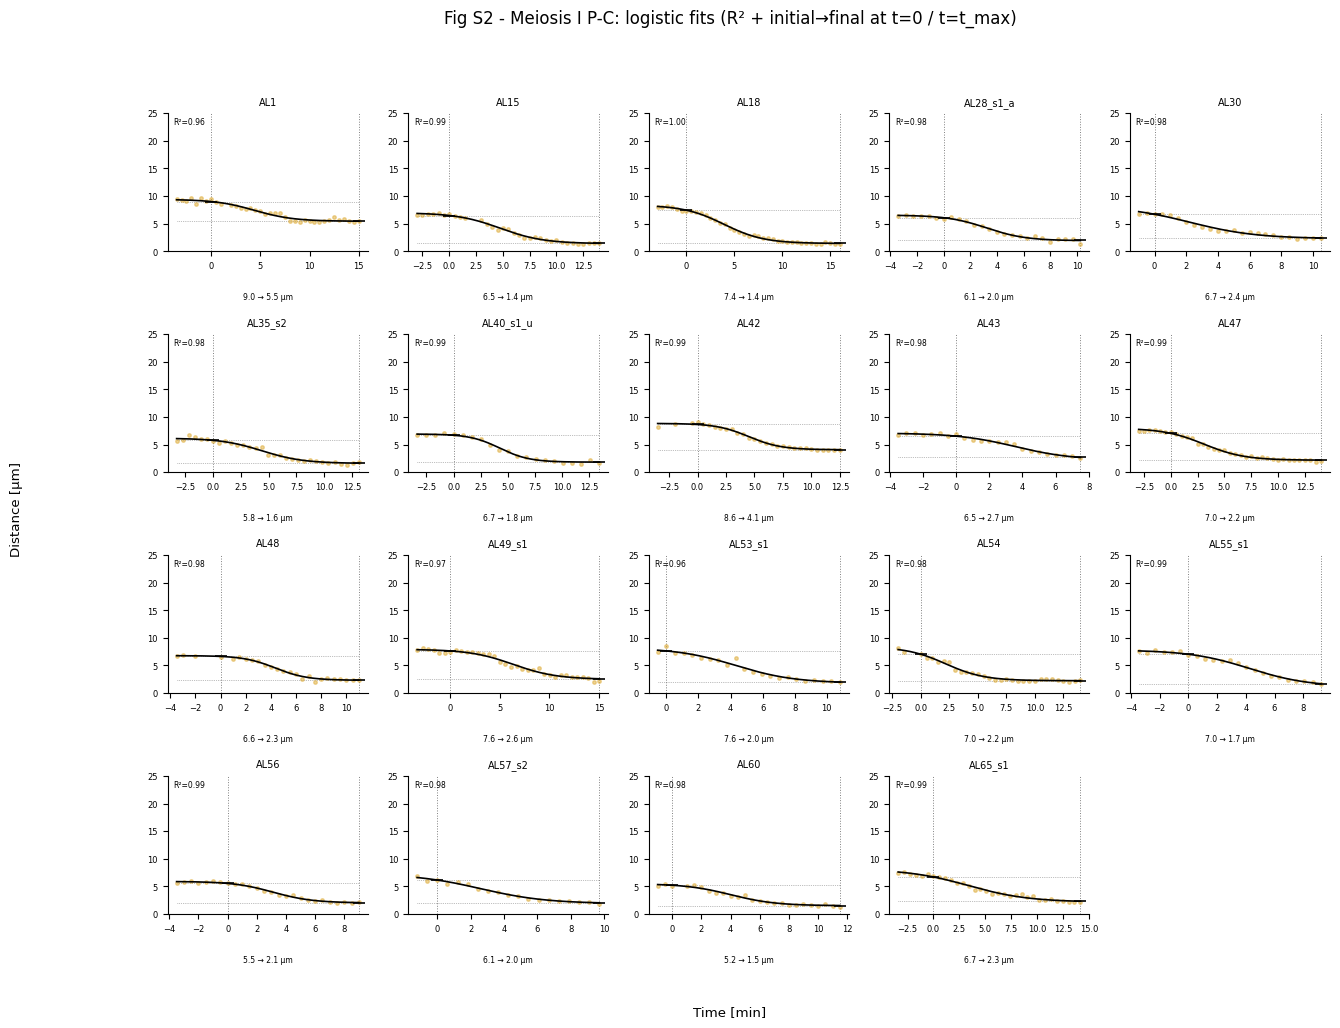

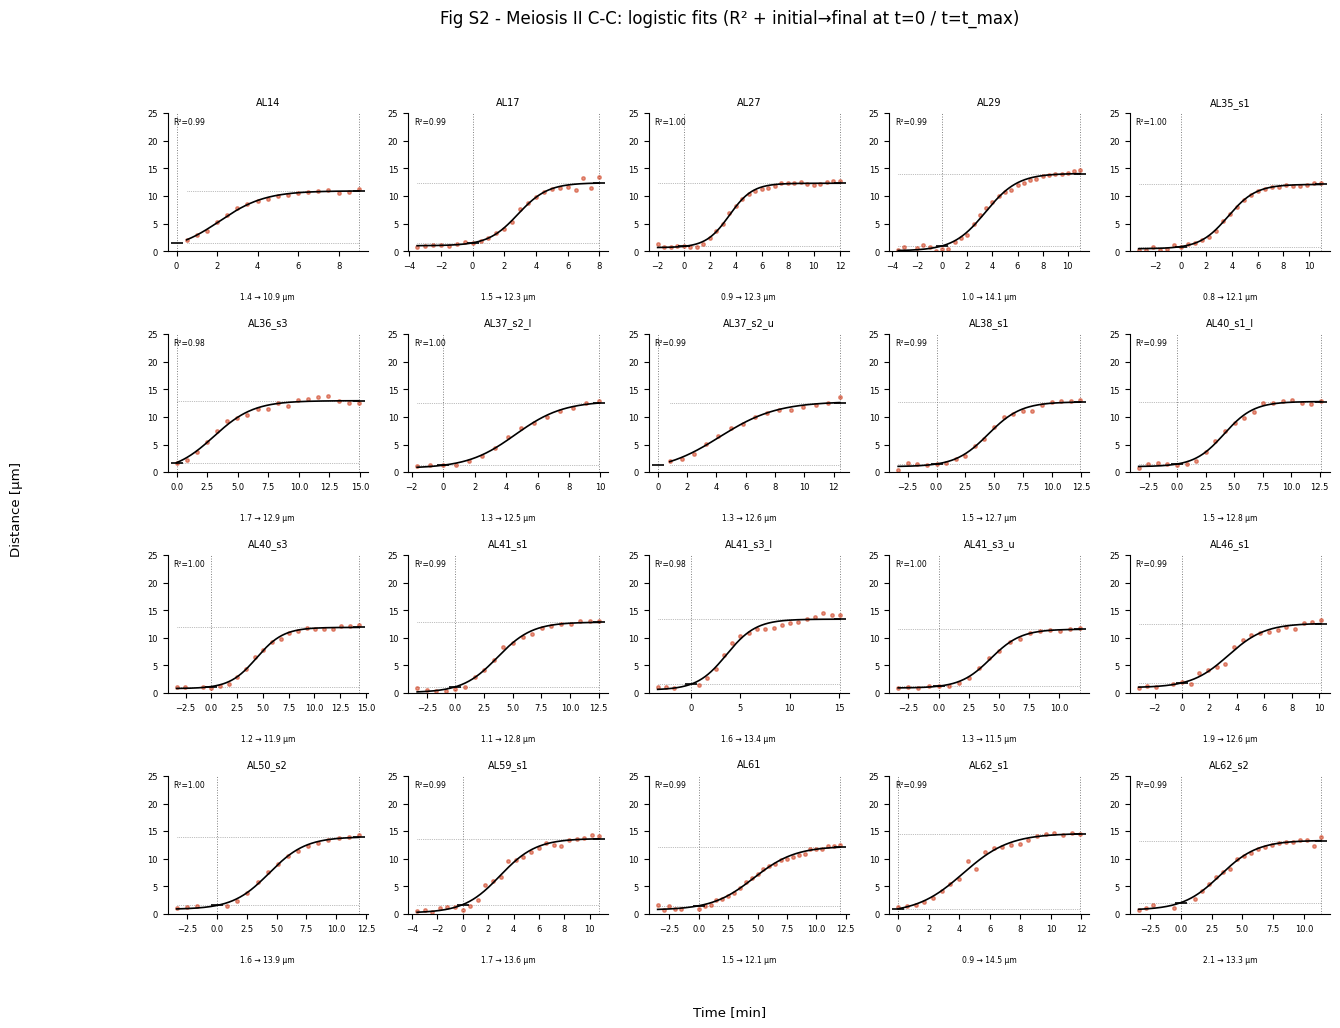

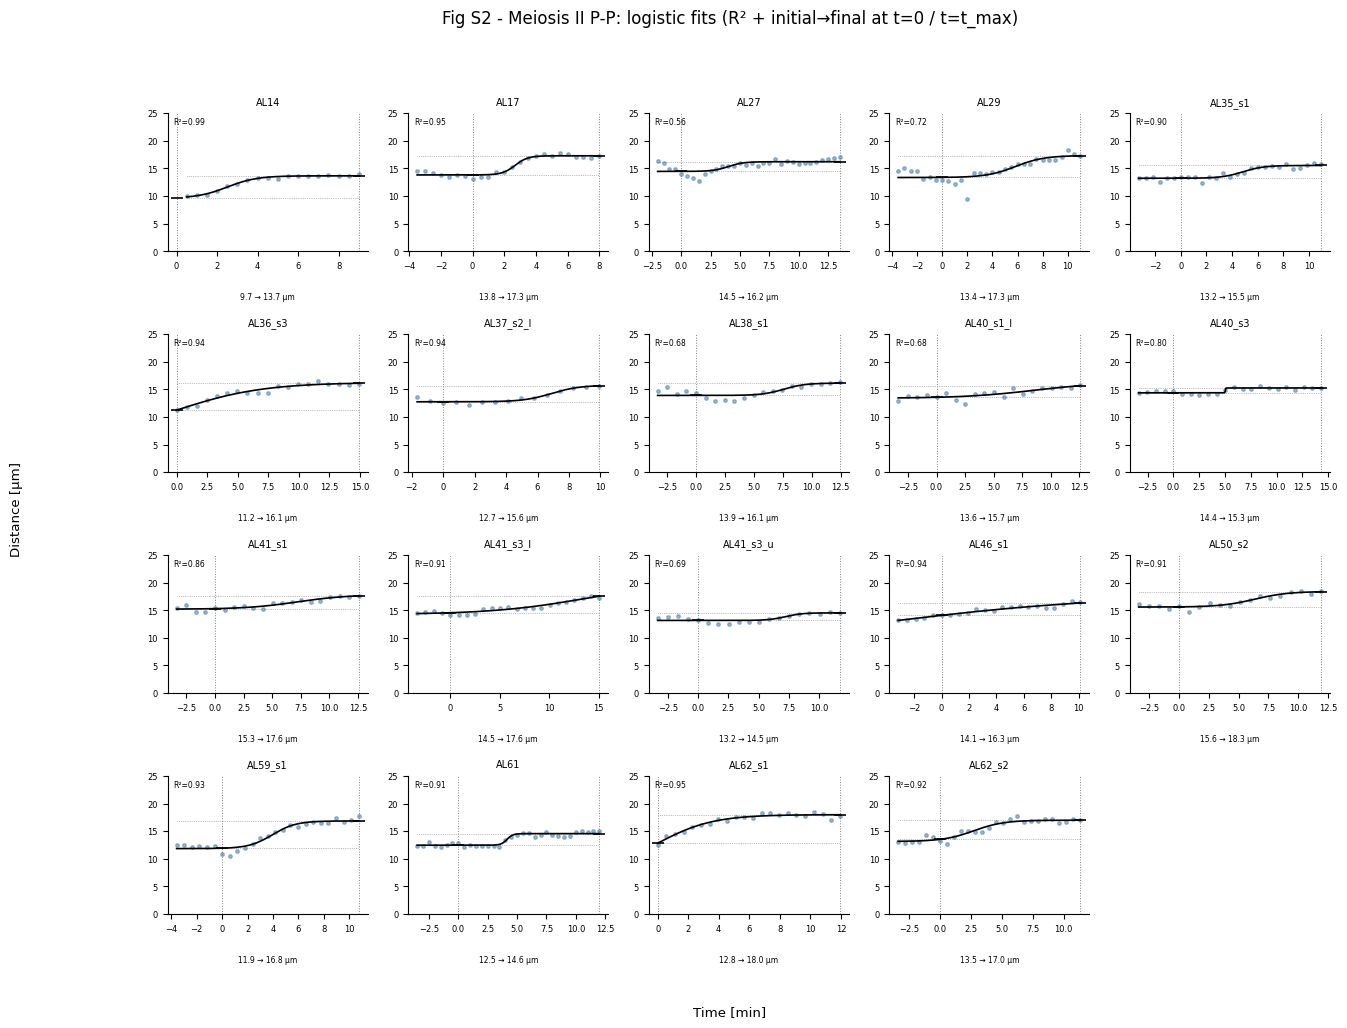

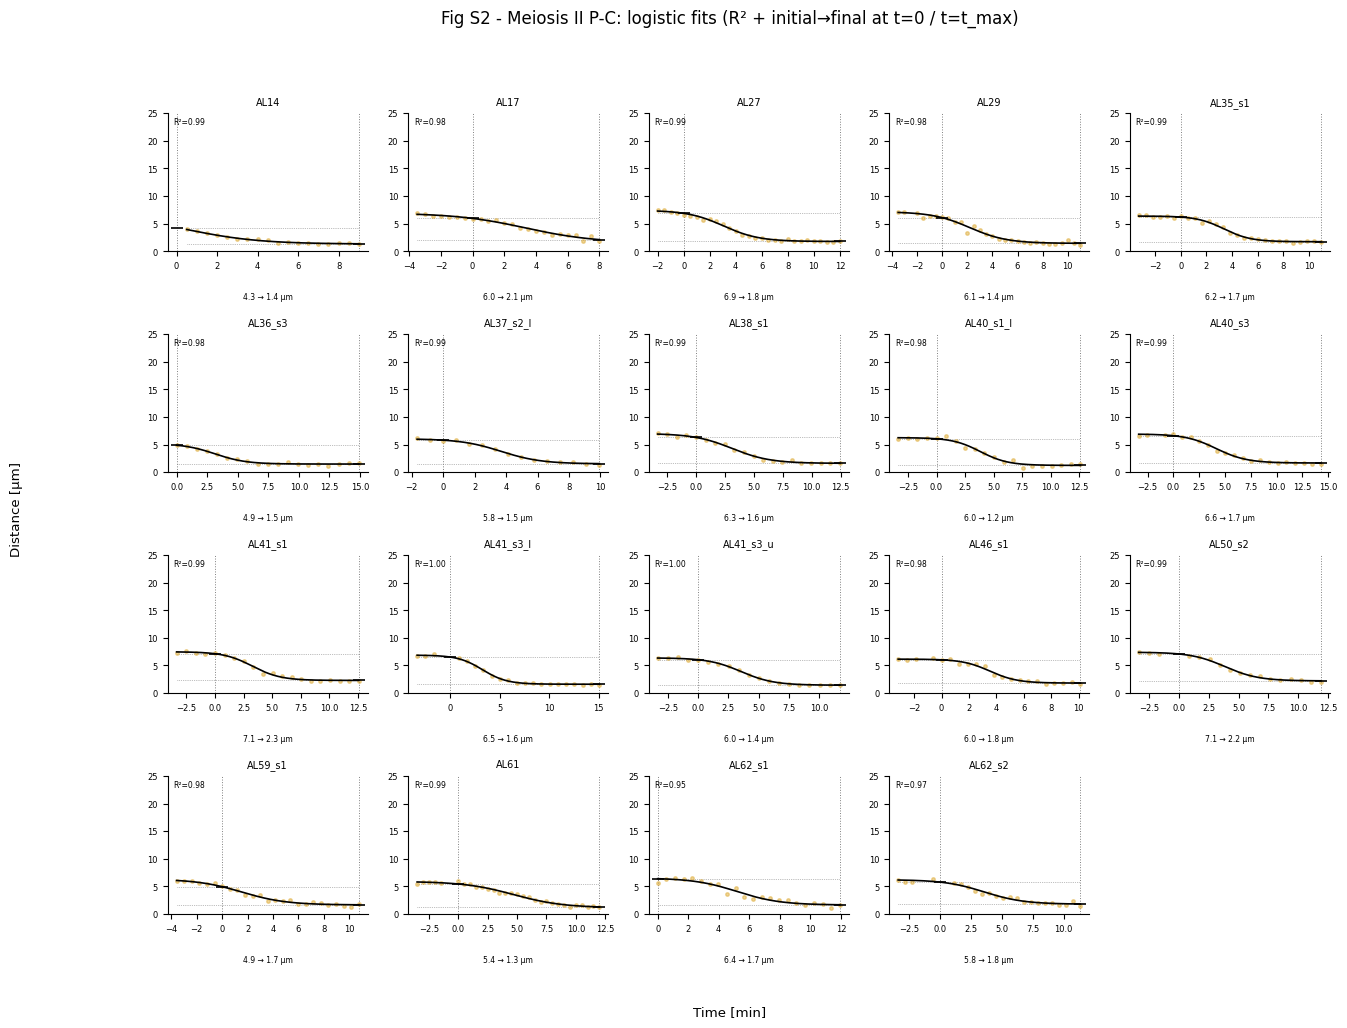

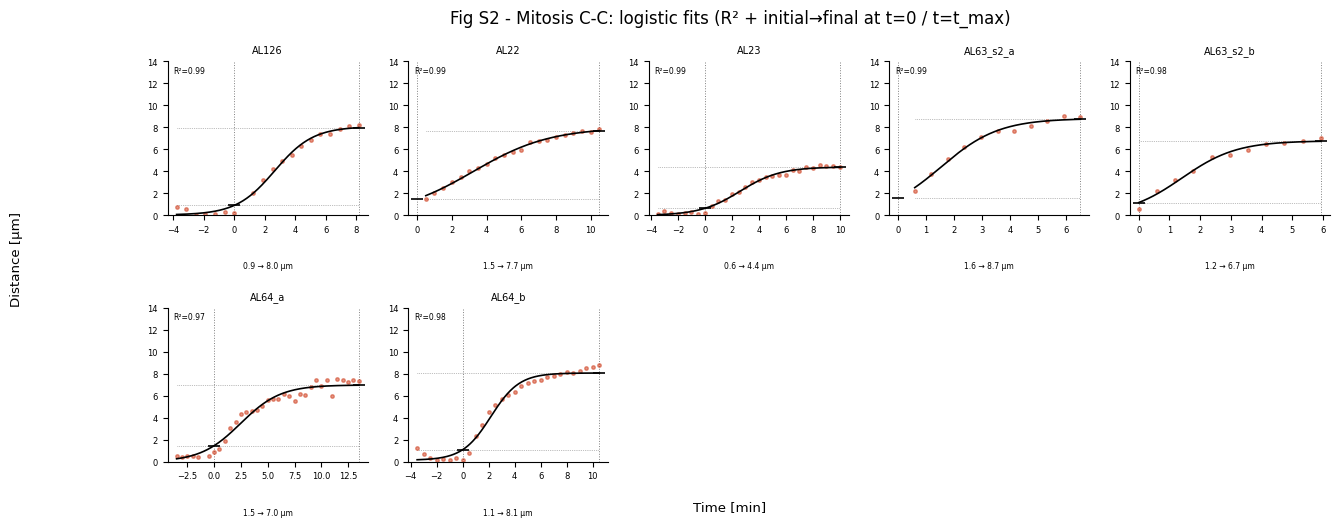

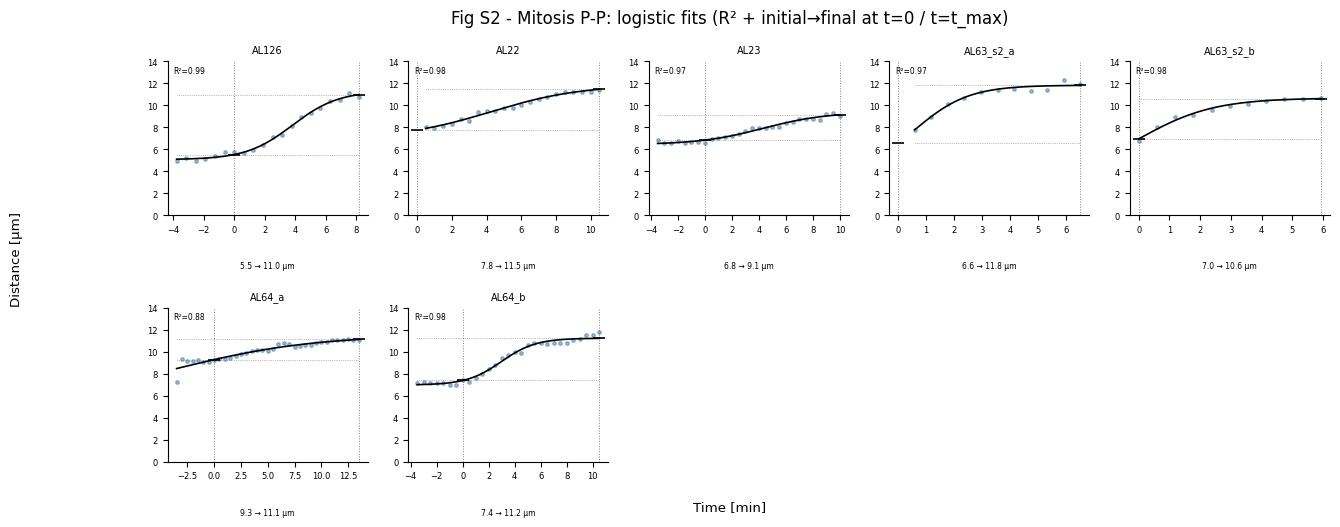

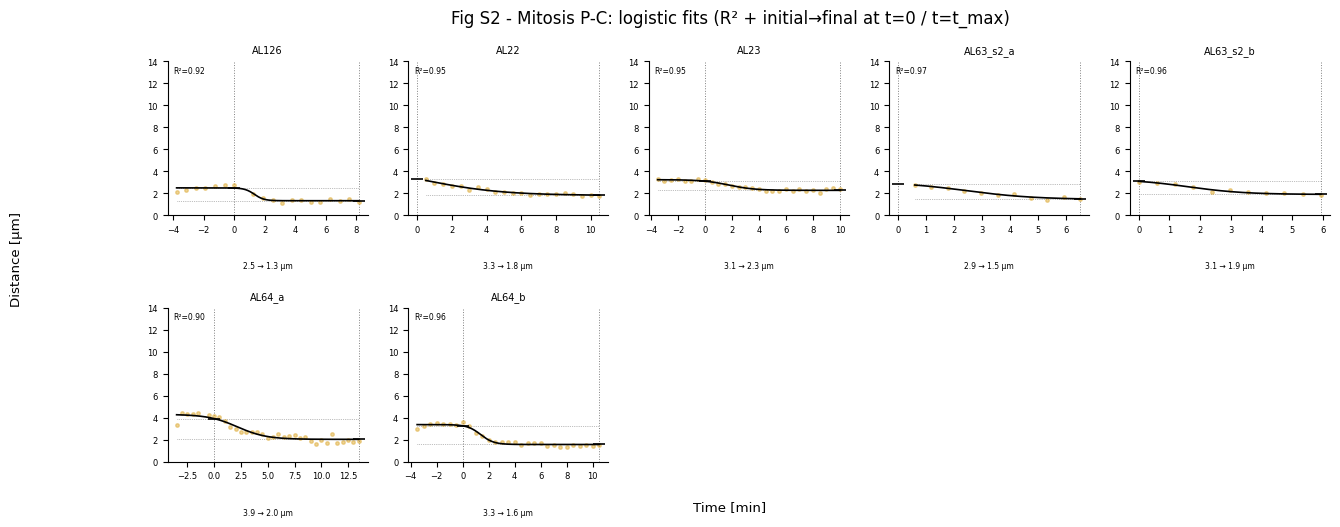

In [19]:
# Fig S2 - per-cell LOGISTIC fits. One page per division x measure: raw points +
# the fitted logistic (thin line). Two dotted guide lines mark WHERE the reported
# distances are read from the curve: at anaphase onset (t=0 -> initial = d(0))
# and at the last frame (t_max -> final = d(t_max)). Annotated with logistic R²
# (top) and initial -> final (below). Y-axis fixed per division.
def fig_s2_logistic(division, measure, key, col, ylim, ncol=5, fname=None):
    ok_f = fits[(fits.division == division) & (fits.measure == measure)
                & (fits.status == "ok")].sort_values("cell")
    cells = ok_f.cell.tolist(); n = len(cells); nrow = int(np.ceil(n/ncol))
    if n == 0:
        print(f"no OK {measure} fits for {division}"); return
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.0*ncol, 2.6*nrow), squeeze=False)
    fig.subplots_adjust(hspace=0.6)
    src = (pc_data[division] if measure == "P-C" else data[(division, key)])
    for j, cell in enumerate(cells):
        ax = axes[j // ncol][j % ncol]
        r = ok_f[ok_f.cell == cell].iloc[0]
        g = src[src.cell == cell].sort_values("time_s")
        ax.plot(g.time_s/60.0, g.dist_um, "o", ms=2.5, color=col, alpha=0.5)
        tt = np.linspace(g.time_s.min(), g.time_s.max(), 300)
        ax.plot(tt/60.0, sigmoid(tt, r["a"], r["b"], r["t0"], r["k"]),
                "-", lw=1.2, color="k")

        # --- read-off guide lines: where initial=d(0) and final=d(t_max) come from
        t_ini, t_fin = 0.0, g.time_s.max()               # in seconds
        y_ini, y_fin = r["initial"], r["final"]
        for tx, yv in ((t_ini, y_ini), (t_fin, y_fin)):
            ax.axvline(tx/60.0, color="0.5", ls=":", lw=0.7, zorder=1)   # vertical at t
            ax.plot([tx/60.0], [yv], marker="_", ms=8, mec="k", mew=1.2, # tick at read-off height
                    color="k", zorder=4)
        ax.hlines([y_ini, y_fin], g.time_s.min()/60.0, g.time_s.max()/60.0,
                  color="0.5", ls=":", lw=0.5, zorder=1)                 # faint level lines

        ax.set_ylim(*ylim); ax.set_title(cell, fontsize=7); ax.tick_params(labelsize=6)
        ax.text(0.03, 0.97, f"R²={r['r2_log']:.2f}", transform=ax.transAxes,
                fontsize=5.5, va="top")
        ax.text(0.5, -0.30, f"{r['initial']:.1f} → {r['final']:.1f} µm",
                transform=ax.transAxes, fontsize=5.5, ha="center", va="top")
    for j in range(n, nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.supxlabel("Time [min]"); fig.supylabel("Distance [µm]")
    fig.suptitle(f"Fig S2 - {division} {measure}: logistic fits "
                 f"(R² + initial→final at t=0 / t=t_max)", fontsize=12)
    if fname:
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight")
    plt.show()

for div, tag, yl in [("Meiosis I","MeiosisI",(0,25)), ("Meiosis II","MeiosisII",(0,25)),
                     ("Mitosis","Mitosis",(0,14))]:
    fig_s2_logistic(div, "C-C", "chr-to-chr",   MEAS["C-C"], yl, fname=f"FigS2_{tag}_CC_logistic.pdf")
    fig_s2_logistic(div, "P-P", "pole-to-pole", MEAS["P-P"], yl, fname=f"FigS2_{tag}_PP_logistic.pdf")
    fig_s2_logistic(div, "P-C", None,           MEAS["P-C"], yl, fname=f"FigS2_{tag}_PC_logistic.pdf")


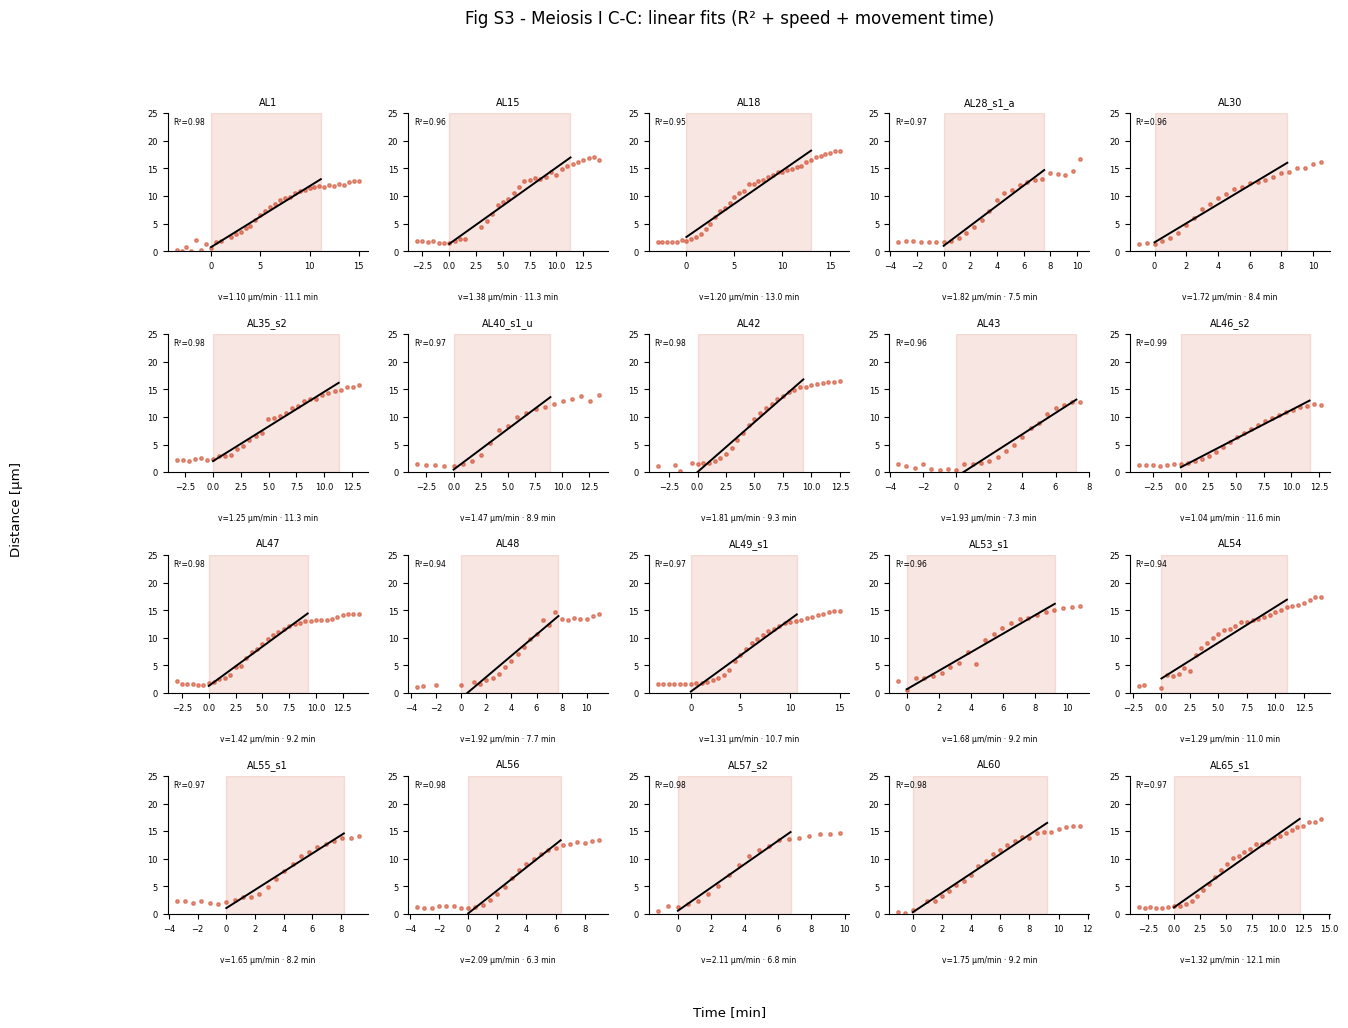

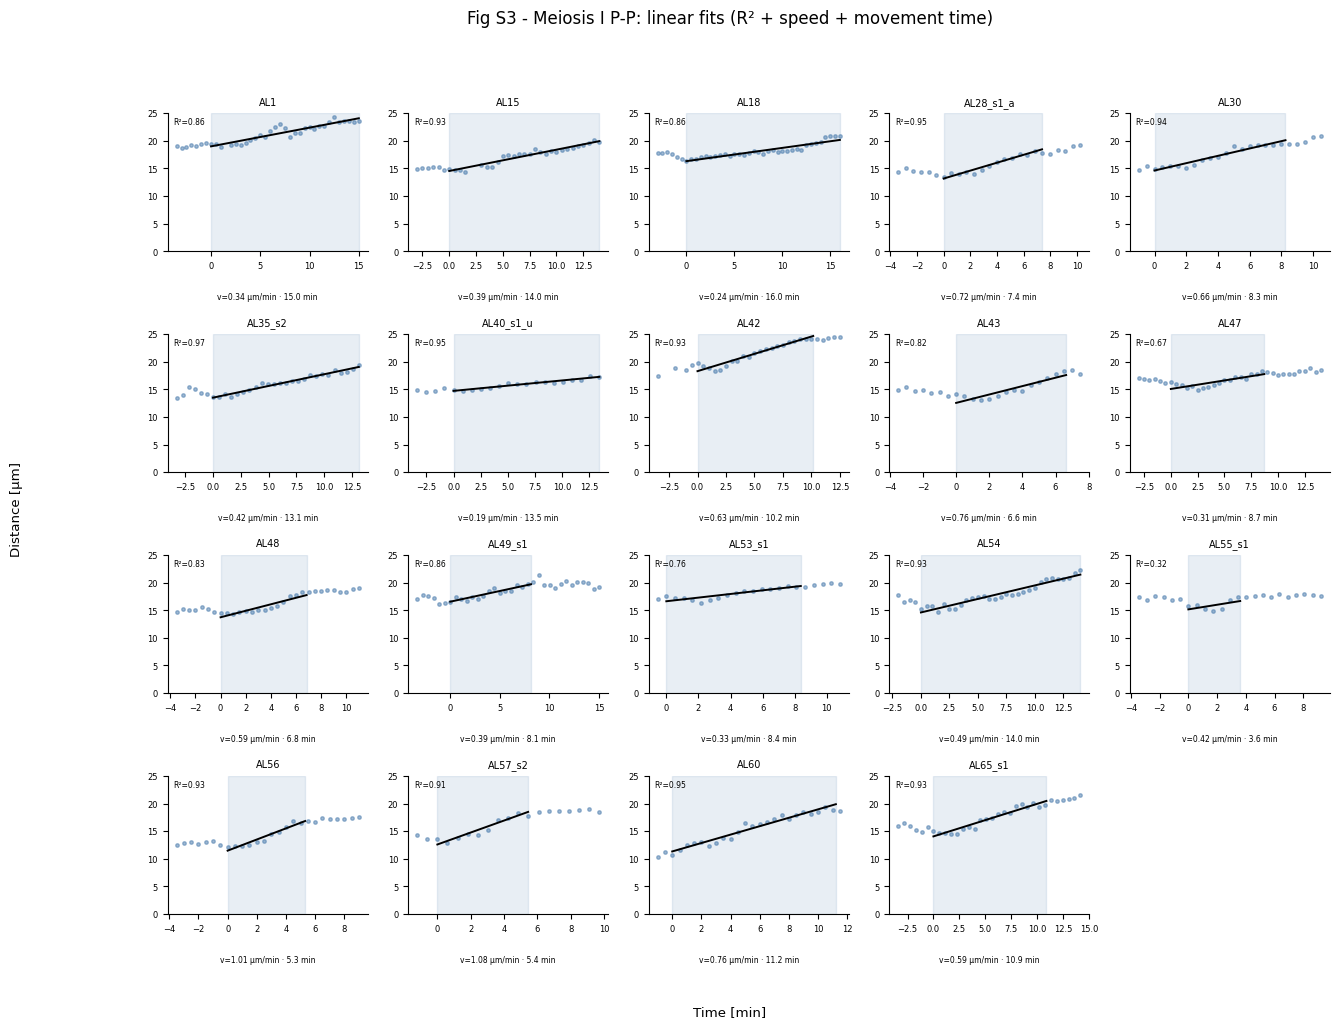

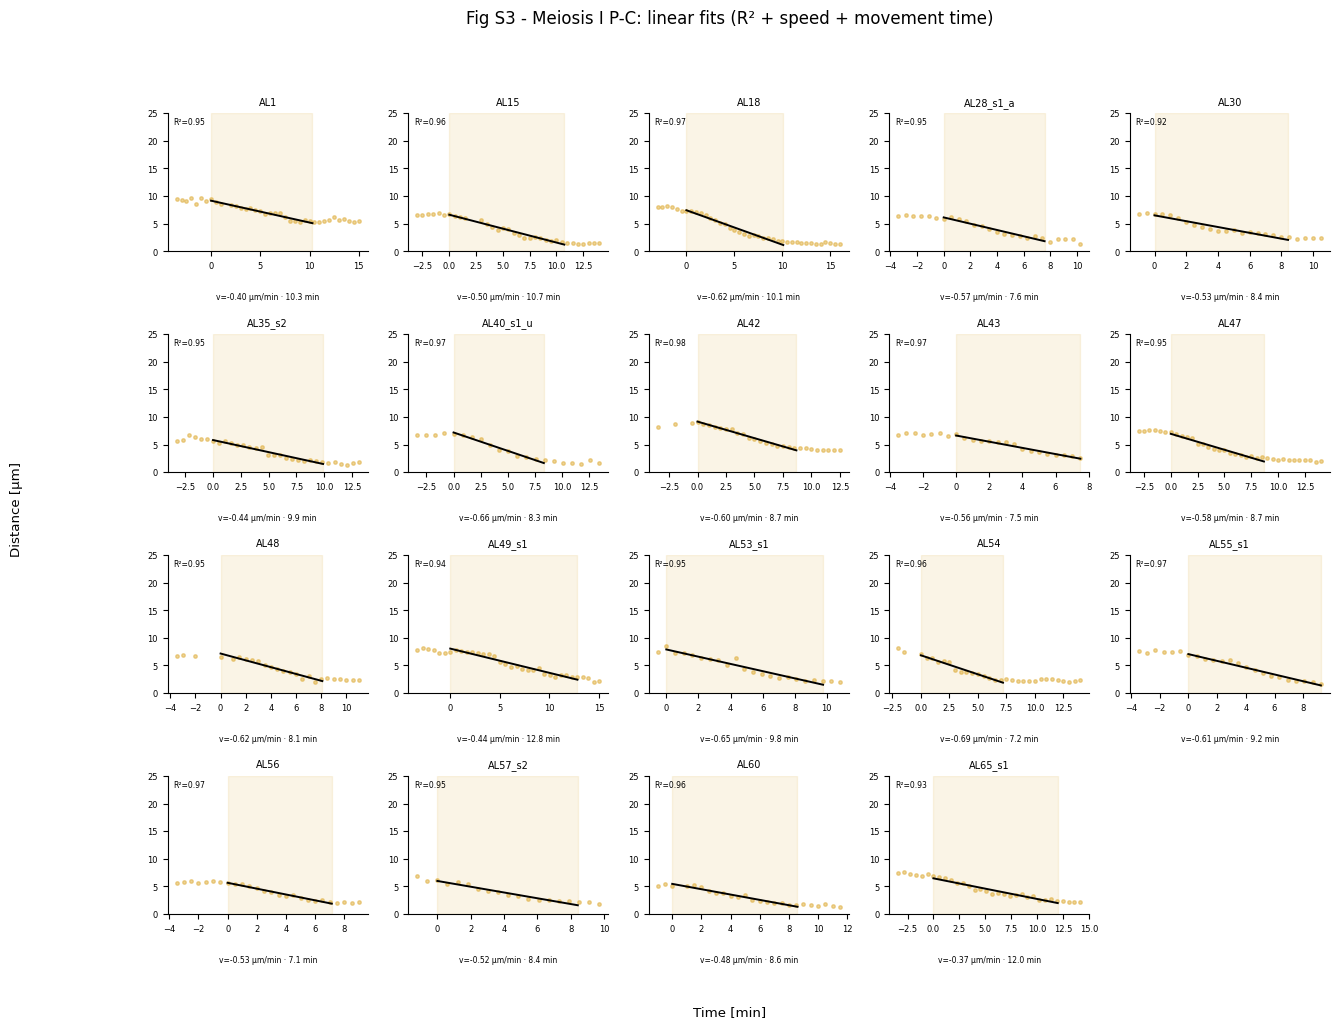

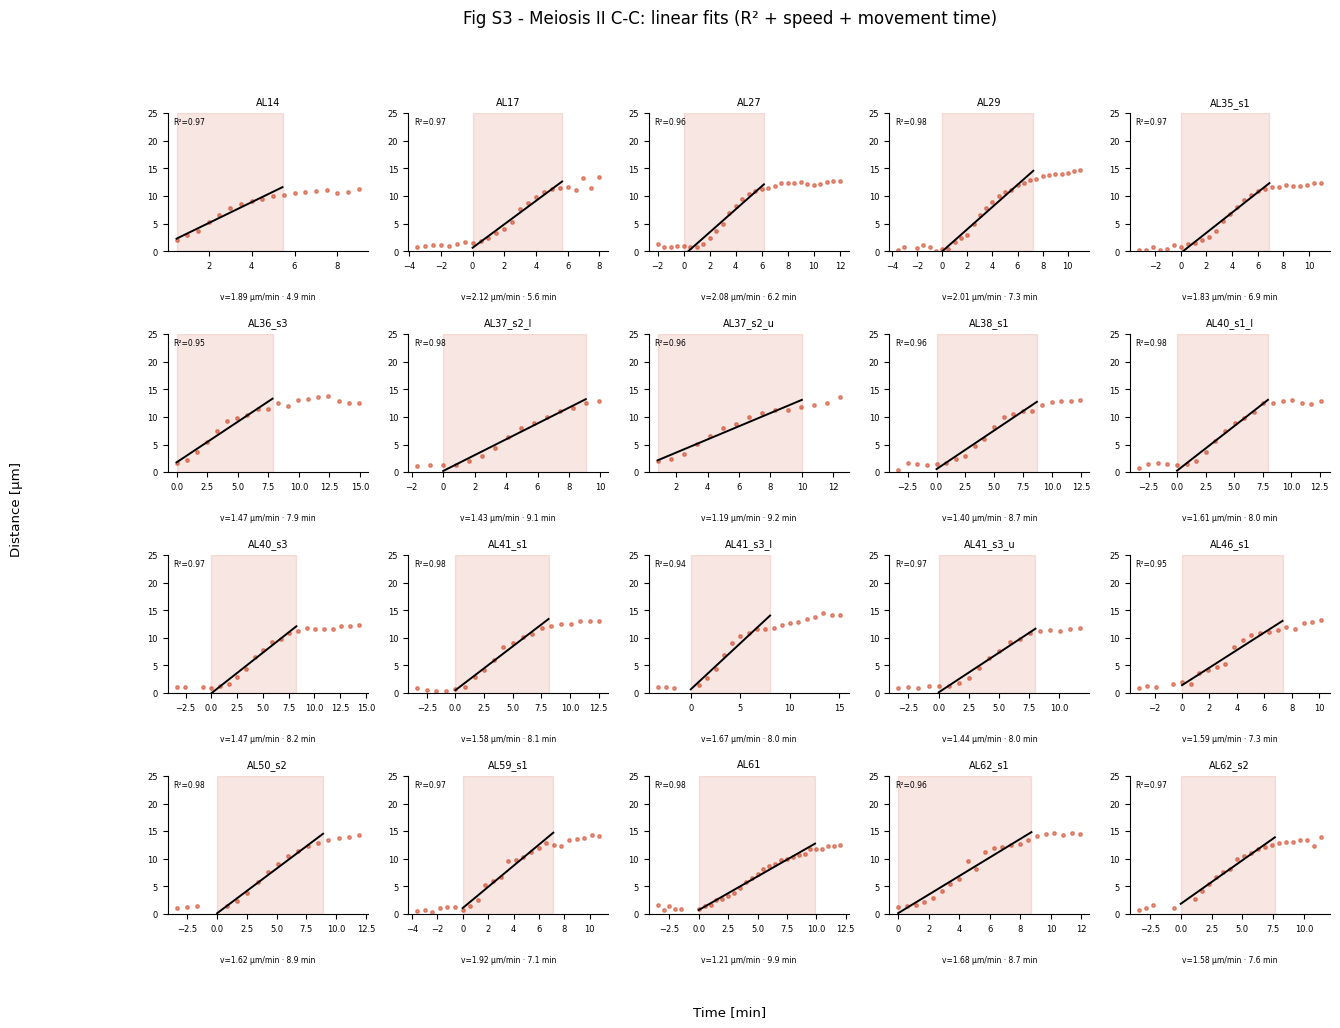

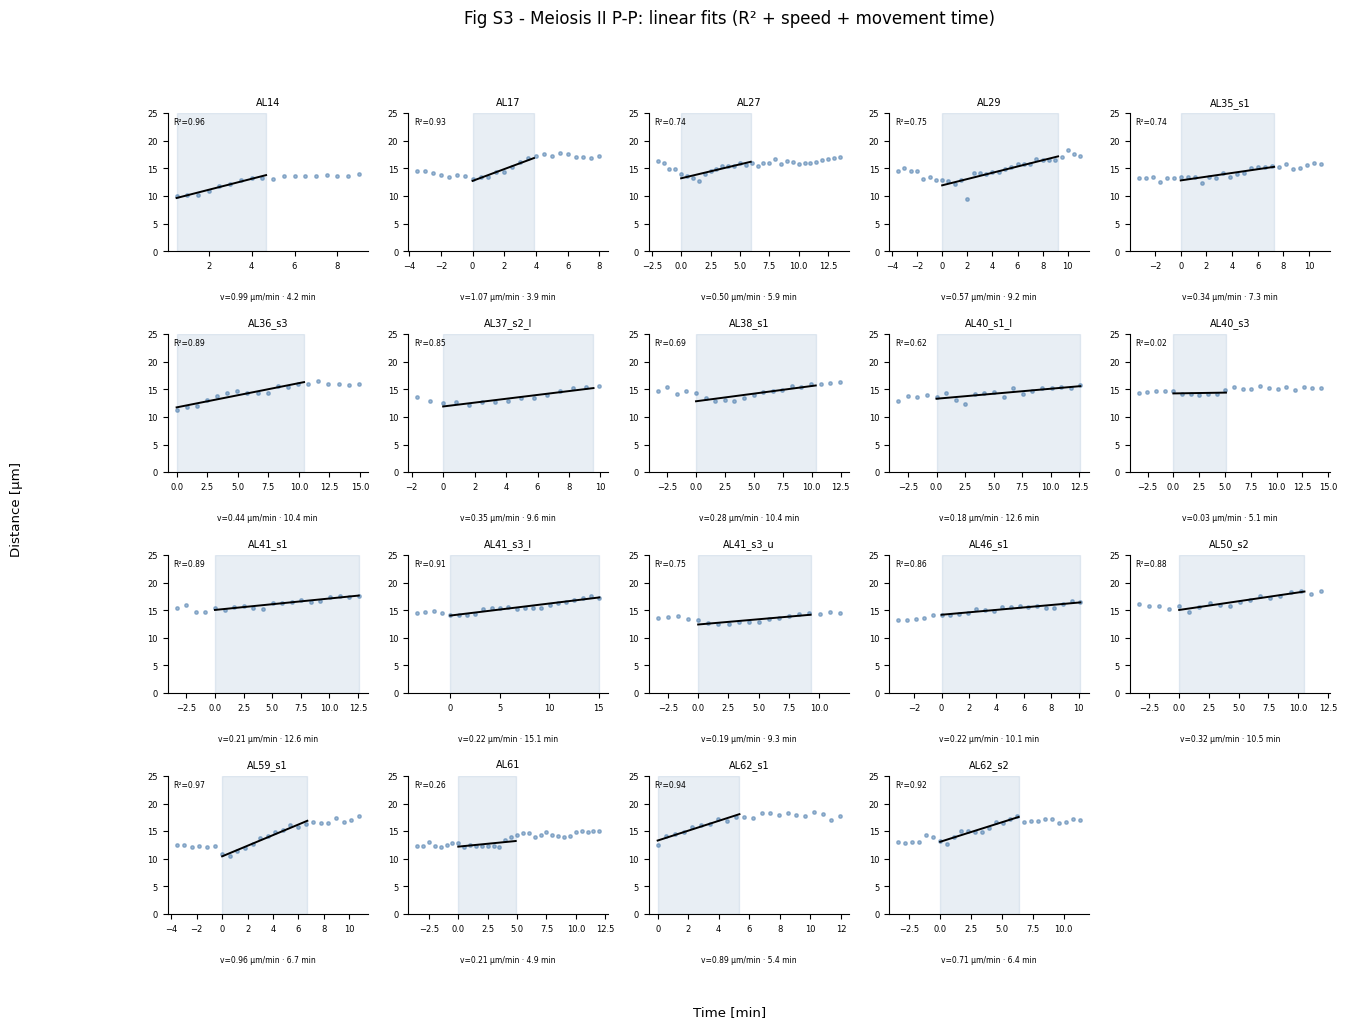

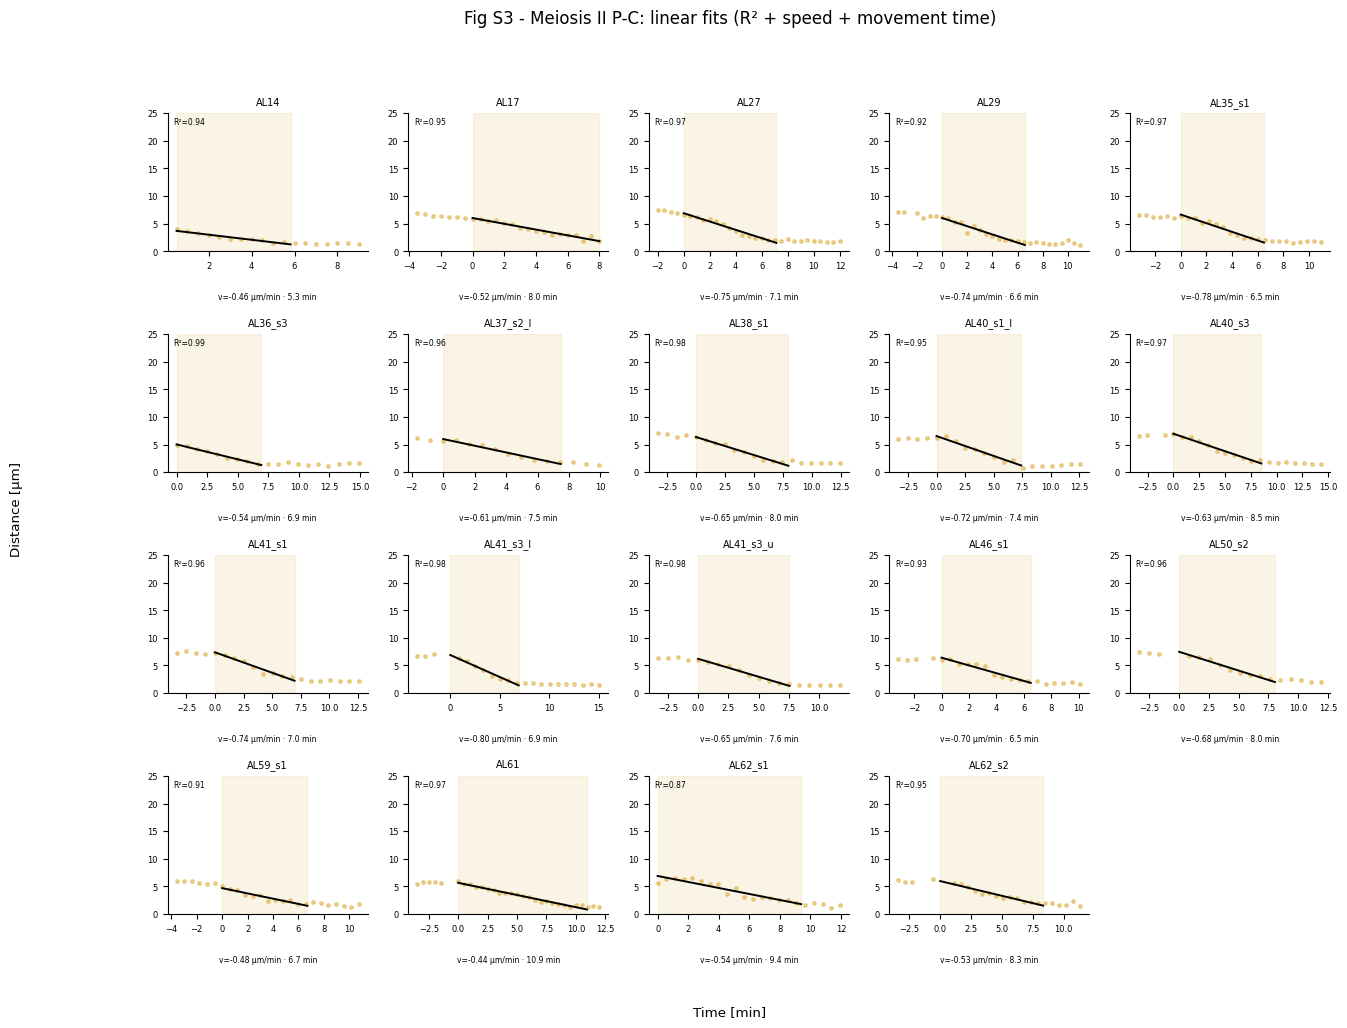

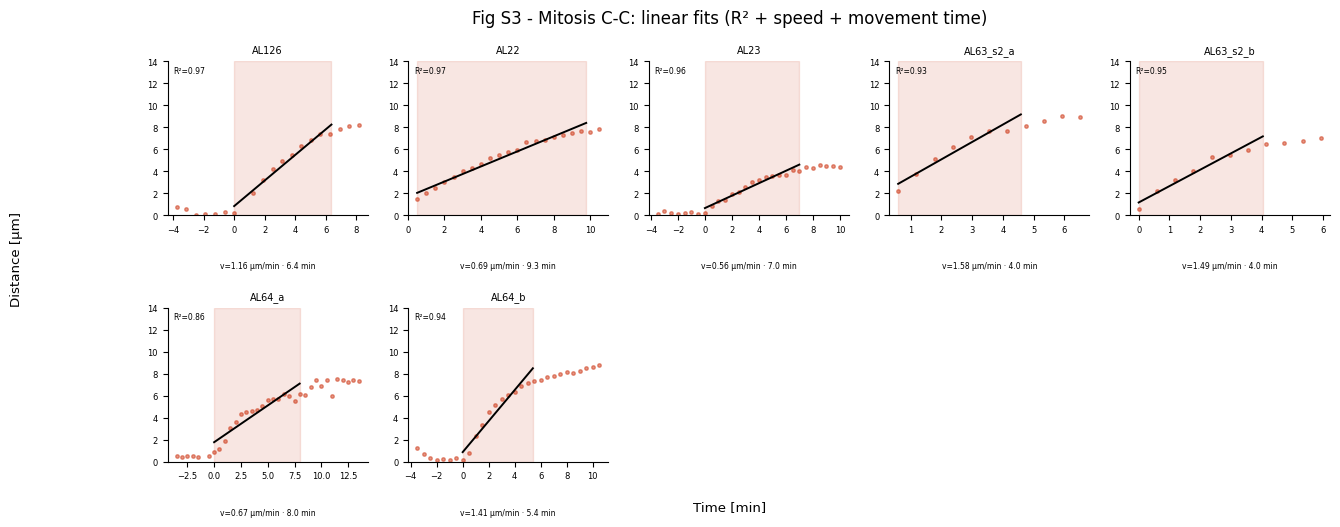

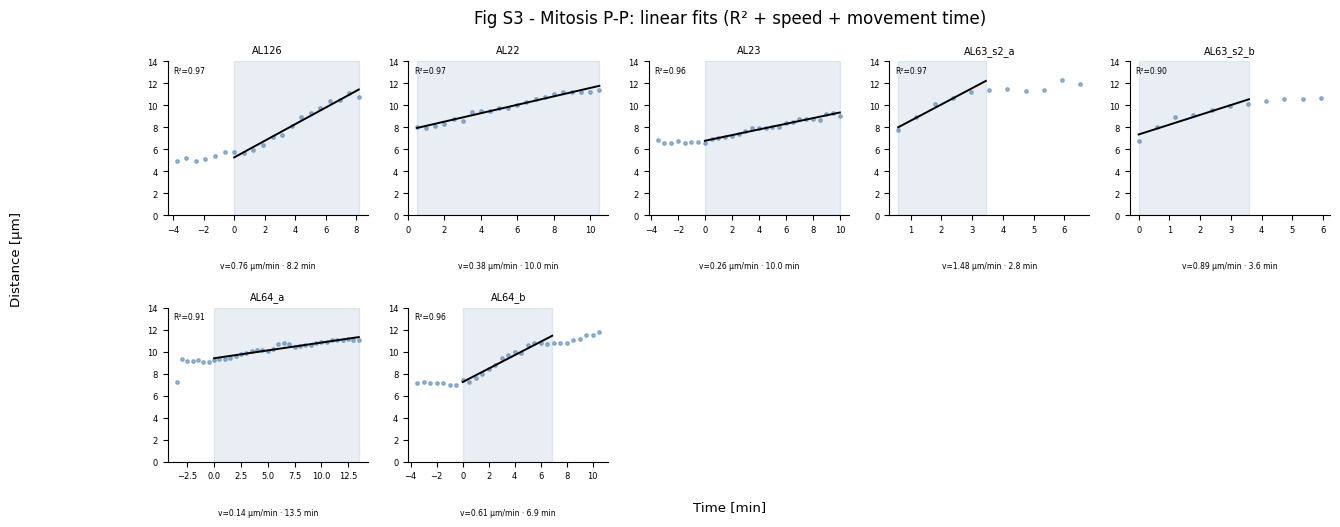

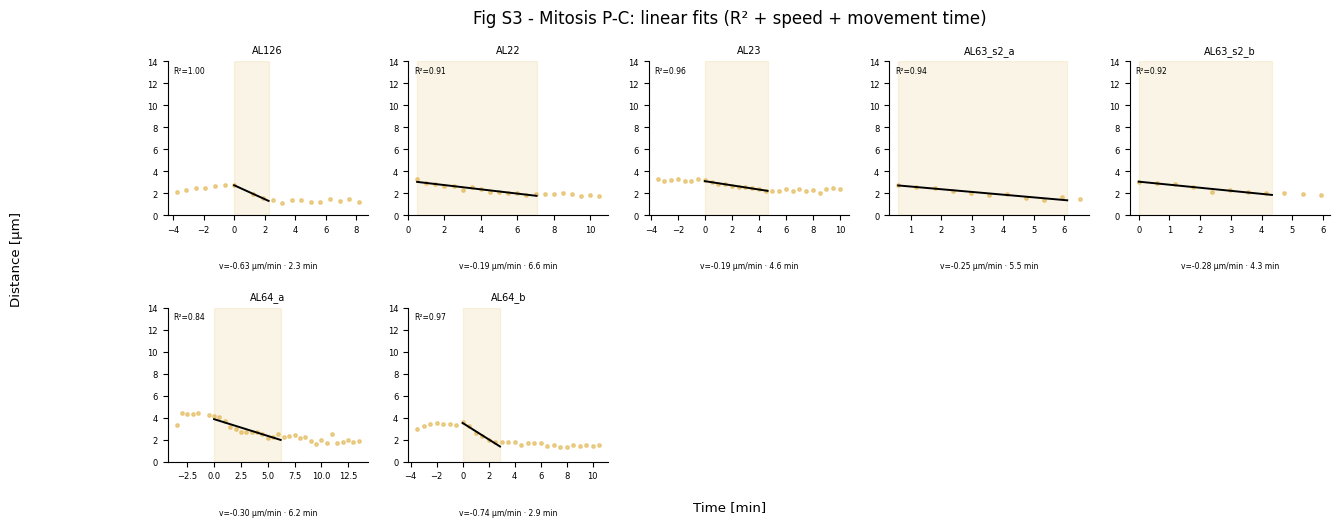

In [20]:
# Fig S3 - per-cell LINEAR speed fits. One page per division x measure: raw
# points + the linear fit (thin line) over its movement window (shaded).
# Annotated with linear R² (top) and, below: the reported SPEED and the
# MOVEMENT TIME (window width = the shaded region). Y-axis fixed per division.
def fig_s3_linear(division, measure, key, col, ylim, ncol=5, fname=None):
    ok_f = fits[(fits.division == division) & (fits.measure == measure)
                & (fits.status == "ok")].sort_values("cell")
    cells = ok_f.cell.tolist(); n = len(cells); nrow = int(np.ceil(n/ncol))
    if n == 0:
        print(f"no OK {measure} fits for {division}"); return
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.0*ncol, 2.6*nrow), squeeze=False)
    fig.subplots_adjust(hspace=0.6)                          # room for below-panel text
    src = (pc_data[division] if measure == "P-C" else data[(division, key)])
    for j, cell in enumerate(cells):
        ax = axes[j // ncol][j % ncol]
        r = ok_f[ok_f.cell == cell].iloc[0]
        g = src[src.cell == cell].sort_values("time_s")
        ax.plot(g.time_s/60.0, g.dist_um, "o", ms=2.5, color=col, alpha=0.5)
        tw = np.array([r["t_start"], r["t_end"]])
        ax.plot(tw/60.0, r["lin_slope"]*tw + r["lin_intercept"], "-", lw=1.4, color="k")
        ax.axvspan(r["t_start"]/60.0, r["t_end"]/60.0, color=col, alpha=0.12)
        ax.set_ylim(*ylim); ax.set_title(cell, fontsize=7); ax.tick_params(labelsize=6)
        ax.text(0.03, 0.97, f"R²={r['r2_lin']:.2f}", transform=ax.transAxes,
                fontsize=5.5, va="top")
        ax.text(0.5, -0.30, f"v={r['speed']:.2f} µm/min · {r['move_time']:.1f} min",
                transform=ax.transAxes, fontsize=5.5, ha="center", va="top")
    for j in range(n, nrow*ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.supxlabel("Time [min]"); fig.supylabel("Distance [µm]")
    fig.suptitle(f"Fig S3 - {division} {measure}: linear fits (R² + speed + movement time)", fontsize=12)
    if fname:
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight")
    plt.show()

for div, tag, yl in [("Meiosis I","MeiosisI",(0,25)), ("Meiosis II","MeiosisII",(0,25)),
                     ("Mitosis","Mitosis",(0,14))]:
    fig_s3_linear(div, "C-C", "chr-to-chr",   MEAS["C-C"], yl, fname=f"FigS3_{tag}_CC_speed.pdf")
    fig_s3_linear(div, "P-P", "pole-to-pole", MEAS["P-P"], yl, fname=f"FigS3_{tag}_PP_speed.pdf")
    fig_s3_linear(div, "P-C", None,           MEAS["P-C"], yl, fname=f"FigS3_{tag}_PC_speed.pdf")


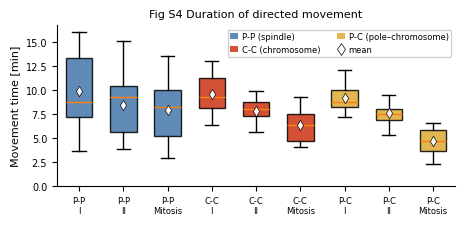

In [21]:
# Fig S4 - movement time (duration of directed movement = the shaded window in
# S3) per division x measure. Boxes coloured by measure (P-P blue, C-C red,
# P-C sand); white diamond = mean (outline 0.5 px here only). Answers "how long
# does directed movement last?" (meiosis ~5 min longer than mitosis ~3 min).
MEAN_KW_S4 = {**MEAN_KW, "linewidths": 0.5}          # thinner diamond edge, this plot only

fig, ax = plt.subplots(figsize=(FIG4_W*2, FIG4_W))
groups, labels, cols = [], [], []
for meas in ("P-P", "C-C", "P-C"):
    for div in DIVISIONS:
        v = ok[(ok.division == div) & (ok.measure == meas)].move_time.dropna().values
        groups.append(v); labels.append(f"{meas}\n{div.split()[-1]}"); cols.append(MEAS[meas])
positions = np.arange(len(groups))
bp = ax.boxplot(groups, positions=positions, widths=0.6, patch_artist=True,
                showmeans=False, showfliers=False)
for patch, c in zip(bp["boxes"], cols): patch.set(facecolor=c, alpha=0.85)
ax.scatter(positions, [g.mean() for g in groups], **MEAN_KW_S4)

# legend: the three measures (box colours) + the mean marker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [Patch(facecolor=MEAS["P-P"], alpha=0.85, label="P-P (spindle)"),
           Patch(facecolor=MEAS["C-C"], alpha=0.85, label="C-C (chromosome)"),
           Patch(facecolor=MEAS["P-C"], alpha=0.85, label="P-C (pole–chromosome)"),
           Line2D([], [], marker="d", ls="", mfc="white", mec="black",
                  mew=0.5, ms=6, label="mean")]
ax.legend(handles=handles, loc="upper right", fontsize=6, frameon=True,
          framealpha=0.9, handlelength=1.0, handletextpad=0.4, borderpad=0.3, ncol=2)

ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel("Movement time [min]"); ax.set_ylim(0, None)
ax.set_title("Fig S4 Duration of directed movement")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "FigS4_movement_time.pdf"), bbox_inches="tight"); plt.show()

## 8. Tables 1 & 2

In [22]:
# Table 1 - auto-generated from the pipeline `ok` fits. Rows: Division x
# {n, Average, SD}; Columns: 9 measures with UNITS IN THE HEADER [µm]/[µm/min],
# so cells hold numbers only (cleaner). initial = metaphase plateau (a),
# final = anaphase plateau (a+b), speed = linear-window slope.
MEAS_ORDER = ["P-P", "C-C", "P-C"]
STAT_COLS  = ["initial", "final", "speed"]

def _col(df, measure, stat):
    d = df[df.measure == measure]
    return {"initial": d.initial, "final": d.final,
            "speed": d.speed}[stat].dropna()

rows = []
for div in DIVISIONS:
    sub = ok[ok.division == div]
    ns, avgs, sds = {}, {}, {}
    for m in MEAS_ORDER:
        for s in STAT_COLS:
            v = _col(sub, m, s); key = f"{m}_{s}"
            ns[key], avgs[key], sds[key] = len(v), v.mean(), v.std()
    rows += [(div, "n", ns), (div, "Average", avgs), (div, "SD", sds)]

cols = [f"{m}_{s}" for m in MEAS_ORDER for s in STAT_COLS]

def _fmt(kind, d):
    out = {}
    for c in cols:
        if kind == "n":
            out[c] = f"{d[c]:d}"
        elif kind == "SD":
            out[c] = f"± {d[c]:.1f}"
        else:
            out[c] = f"{d[c]:.1f}"
    return out

# header labels with units in [], subscript-style measure names as in your image
UNIT = {"initial": "[µm]", "final": "[µm]", "speed": "[µm/min]"}
pretty = {f"{m}_{s}": f"{m}$_{{{s}}}$ {UNIT[s]}"
          for m in MEAS_ORDER for s in STAT_COLS}
# plain-text version (for CSV/Excel where LaTeX subscripts won't render)
pretty_plain = {f"{m}_{s}": f"{m} {s} {UNIT[s]}"
                for m in MEAS_ORDER for s in STAT_COLS}

table1 = pd.DataFrame(
    [_fmt(kind, d) for (_, kind, d) in rows],
    index=pd.MultiIndex.from_tuples([(div, kind) for (div, kind, _) in rows],
                                    names=["Division", ""]),
    columns=cols).rename(columns=pretty_plain)

table1.to_csv(os.path.join(FIG_DIR, "Table1_dynamics.csv"))
with pd.ExcelWriter(os.path.join(FIG_DIR, "Table1_dynamics.xlsx")) as xw:
    table1.to_excel(xw, sheet_name="Table1")
print(table1.to_string())
print("\nwrote Table1_dynamics.csv and .xlsx")


                   P-P initial [µm] P-P final [µm] P-P speed [µm/min] C-C initial [µm] C-C final [µm] C-C speed [µm/min] P-C initial [µm] P-C final [µm] P-C speed [µm/min]
Division                                                                                                                                                                   
Meiosis I  n                     19             19                 19               20             20                 20               19             19                 19
           Average             15.4           19.6                0.5              1.8           14.6                1.6              6.8            2.3               -0.5
           SD                 ± 2.0          ± 2.0              ± 0.2            ± 0.5          ± 1.5              ± 0.3            ± 1.0          ± 1.0              ± 0.1
Meiosis II n                     19             19                 19               20             20                 20               19   

In [23]:
# Table 2 - Anaphase contributions + cell size. A/B from per_cell_ab; cell area
# from the merged `area` df (column literally named 'area', in µm²). Diameter is
# NOT stored here, so it is computed from area as d = 2*sqrt(area/pi) (the same
# circle-equivalent formula used in Methods). Units in [] for the last two cols.

def _size_stats(div):
    a = area[area.division == div]["area"].dropna()
    d = 2.0 * np.sqrt(a / np.pi)
    return a, d

COLS = ["Anaphase A contribution (P-C) [%]",
        "Anaphase B contribution (P-P) [%]",
        "Cell area [µm²]", "Cell diameter [µm]"]

rows, index = [], []
for div in DIVISIONS:
    A = per_cell_ab[div].A.dropna(); B = per_cell_ab[div].B.dropna()
    ca, cd = _size_stats(div)
    n_ab, n_sz = len(A), len(ca)
    rows.append({COLS[0]: f"{n_ab:d}", COLS[1]: f"{n_ab:d}",
                 COLS[2]: f"{n_sz:d}", COLS[3]: f"{n_sz:d}"});                 index.append((div, "n"))
    rows.append({COLS[0]: f"{A.mean():.1f} %", COLS[1]: f"{B.mean():.1f} %",
                 COLS[2]: f"{ca.mean():.1f}",  COLS[3]: f"{cd.mean():.1f}"});   index.append((div, "Average"))
    rows.append({COLS[0]: f"± {A.std():.1f} %", COLS[1]: f"± {B.std():.1f} %",
                 COLS[2]: f"± {ca.std():.1f}",  COLS[3]: f"± {cd.std():.1f}"}); index.append((div, "SD"))

table2 = pd.DataFrame(rows,
    index=pd.MultiIndex.from_tuples(index, names=["Division", ""]), columns=COLS)
table2.to_csv(os.path.join(FIG_DIR, "Table2_contributions_size.csv"))
with pd.ExcelWriter(os.path.join(FIG_DIR, "Table2_contributions_size.xlsx")) as xw:
    table2.to_excel(xw, sheet_name="Table2")
print(table2.to_string())
print("\nwrote Table2_contributions_size.csv and .xlsx")


                   Anaphase A contribution (P-C) [%] Anaphase B contribution (P-P) [%] Cell area [µm²] Cell diameter [µm]
Division                                                                                                                 
Meiosis I  n                                      19                                19              20                 20
           Average                            68.1 %                            31.9 %           585.4               27.2
           SD                               ± 10.2 %                          ± 10.2 %         ± 104.8              ± 2.4
Meiosis II n                                      19                                19              20                 20
           Average                            74.4 %                            25.6 %           353.3               21.2
           SD                               ± 10.1 %                          ± 10.1 %          ± 46.0              ± 1.4
Mitosis    n            

## 9. Supplementary tables (S1 per-cell, S2 scaling match)

In [24]:
# Table S1 - self-contained: detects the R2 and initial column names inside
# this cell, so it doesn't depend on variables set in an earlier cell (which
# are lost after a kernel restart). Writes both CSV and formatted .xlsx.
R2COL = next((c for c in fits.columns
              if c.lower().replace("_", "").replace(" ", "") in
              ("r2", "rsquared", "rsq", "r2lin", "rsquare")), None)
INITCOL = "initial" if "initial" in fits.columns else \
          next((c for c in fits.columns if "init" in c.lower()), None)
print("detected -> R2COL:", R2COL, "| INITCOL:", INITCOL)

# Table S1 - per-cell master table
cols = ["division", "cell", "measure"]
for c in [INITCOL, "final", "speed", R2COL, "t_start", "t_end"]:
    if c and c in fits.columns:
        cols.append(c)
tbl = fits[fits.status == "ok"][cols].copy()
tbl.to_csv(os.path.join(FIG_DIR, "TableS1_percell.csv"), index=False)
with pd.ExcelWriter(os.path.join(FIG_DIR, "TableS1_percell.xlsx"),
                    engine="xlsxwriter") as xw:
    tbl.to_excel(xw, sheet_name="TableS1", index=False)
    ws = xw.sheets["TableS1"]
    for i, c in enumerate(tbl.columns):
        width = max(len(str(c)), tbl[c].astype(str).map(len).max()) + 2
        ws.set_column(i, i, min(width, 40))
print("Table S1 columns:", cols)


detected -> R2COL: r2_lin | INITCOL: initial
Table S1 columns: ['division', 'cell', 'measure', 'initial', 'final', 'speed', 'r2_lin', 't_start', 't_end']


In [25]:
# Table S2 - merge on BOTH area_dataset AND division. Writes CSV and .xlsx.
cs = cc_scaling[["division", "area_dataset", "matched_cell", "area", "final_CC"]].copy()
ar = area[["dataset", "division", "final_PP"]].copy()

audit = cs.merge(ar, left_on=["area_dataset", "division"],
                 right_on=["dataset", "division"], how="left")
audit = audit.drop(columns=["dataset"])
audit = audit.sort_values(["division", "area_dataset"]).reset_index(drop=True)
audit = audit[["division", "area_dataset", "matched_cell", "area", "final_CC", "final_PP"]]

audit.to_csv(os.path.join(FIG_DIR, "TableS2_scaling_match.csv"), index=False)
with pd.ExcelWriter(os.path.join(FIG_DIR, "TableS2_scaling_match.xlsx"),
                    engine="xlsxwriter") as xw:
    audit.to_excel(xw, sheet_name="TableS2", index=False)
    ws = xw.sheets["TableS2"]
    for i, c in enumerate(audit.columns):
        width = max(len(str(c)),
                    audit[c].astype(str).map(len).max()) + 2
        ws.set_column(i, i, min(width, 40))

print("rows:", len(audit))
print("dup (area_dataset, division):",
      audit.duplicated(["area_dataset", "division"]).sum())
print("dup matched_cell:", audit.matched_cell.duplicated().sum())
print("dup area values:", audit.area.duplicated().sum())
print("missing final_PP:", audit.final_PP.isna().sum(),
      "(expect 2: AL41a/AL41b - area file has no measured final spindle length; "
      "these cells DO have fitted P-P/C-C/P-C tracks)")
print(audit.to_string(index=False))
print("\nwrote TableS2_scaling_match.csv and .xlsx")


rows: 47
dup (area_dataset, division): 0
dup matched_cell: 0
dup area values: 0
missing final_PP: 2 (expect 2: AL41a/AL41b - area file has no measured final spindle length; these cells DO have fitted P-P/C-C/P-C tracks)
  division            area_dataset matched_cell    area  final_CC  final_PP
 Meiosis I                    AL01          AL1  802.60     12.39     23.18
 Meiosis I                  AL15_2         AL15  623.79     16.32     18.49
 Meiosis I                    AL18         AL18  562.03     17.20     19.45
 Meiosis I                  AL28_1    AL28_s1_a  567.86     14.52     18.17
 Meiosis I                    AL30         AL30  468.57     15.16     20.01
 Meiosis I             AL35_scene2      AL35_s2  463.89     15.26     19.38
 Meiosis I       AL40_1_upper cell    AL40_s1_u  466.79     13.23     20.69
 Meiosis I                    AL42         AL42  737.73     16.26     24.51
 Meiosis I                    AL43         AL43  517.67     12.82     18.33
 Meiosis I          